# Combinations

In the previous notebooks we learned:
- **Product rule** and **sum rule** of counting
- **Permutations** — counting **ordered** arrangements

Now we tackle the natural follow-up question:

> **In how many ways can we choose $r$ items from $n$, where order does NOT matter?**

We will:
1. Motivate why permutations overcount when order doesn't matter
2. Derive the combination formula by correcting permutations
3. Explore properties of combinations
4. Work through examples and practice problems

In [1]:
import math
from itertools import permutations, combinations
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


## Table of Contents

1. **Motivating the Problem** — Why permutations overcount when order doesn't matter
2. **Deriving the Combination Formula** — C(n,r) = P(n,r) / r!
3. **Examples** — Real-world applications (committees, lottery, handshakes, poker, etc.)
4. **Properties of Combinations** — Symmetry, Pascal's Identity, Pascal's Triangle, Row sums
5. **Combining Combinations with Product and Sum Rules** — Mixed problems with constraints
6. **Permutations vs Combinations** — When to use which formula
7. **Summary of Formulas** — Quick reference for all formulas
8. **Practice Problems** — 6 problems with solutions
9. **What's Next?** — Stars and Bars (counting with repetition)

---
## 1. Motivating the Problem

Consider choosing **3 people** from a group of 5 — {Alice, Bob, Carol, Dave, Eve} — to form a **committee** (no positions).

Using permutations, $P(5, 3) = 5 \times 4 \times 3 = 60$. But this counts:
- (Alice, Bob, Carol)
- (Alice, Carol, Bob)
- (Bob, Alice, Carol)
- (Bob, Carol, Alice)
- (Carol, Alice, Bob)
- (Carol, Bob, Alice)

as **6 different** arrangements. Yet they all represent the **same committee**: {Alice, Bob, Carol}.

Every group of 3 people was counted $3! = 6$ times (once for each ordering). So permutations **overcounted** by a factor of $3!$.

In [2]:
people = ["Alice", "Bob", "Carol", "Dave", "Eve"]
r = 3

# Permutations: ordered selections
all_perms = list(permutations(people, r))

# Combinations: unordered selections
all_combs = list(combinations(people, r))

print(f"People: {people}")
print(f"Choosing: {r}")
print()
print(f"Permutations P(5,3): {len(all_perms)}")
print(f"Combinations C(5,3): {len(all_combs)}")
print(f"Overcount factor:    {len(all_perms) // len(all_combs)} = {r}! = {math.factorial(r)}")

People: ['Alice', 'Bob', 'Carol', 'Dave', 'Eve']
Choosing: 3

Permutations P(5,3): 60
Combinations C(5,3): 10
Overcount factor:    6 = 3! = 6


In [3]:
# Show the overcount: all 3! = 6 permutations that map to one combination
target = ("Alice", "Bob", "Carol")
target_set = set(target)

matching_perms = []
for p in all_perms:
    if set(p) == target_set:
        matching_perms.append(p)

print(f"The committee {{Alice, Bob, Carol}} appears as {len(matching_perms)} permutations:")
print()
for i, p in enumerate(matching_perms, 1):
    print(f"  {i}. {p}")
print()
print(f"All {len(matching_perms)} are the SAME committee — they differ only in order.")

The committee {Alice, Bob, Carol} appears as 6 permutations:

  1. ('Alice', 'Bob', 'Carol')
  2. ('Alice', 'Carol', 'Bob')
  3. ('Bob', 'Alice', 'Carol')
  4. ('Bob', 'Carol', 'Alice')
  5. ('Carol', 'Alice', 'Bob')
  6. ('Carol', 'Bob', 'Alice')

All 6 are the SAME committee — they differ only in order.


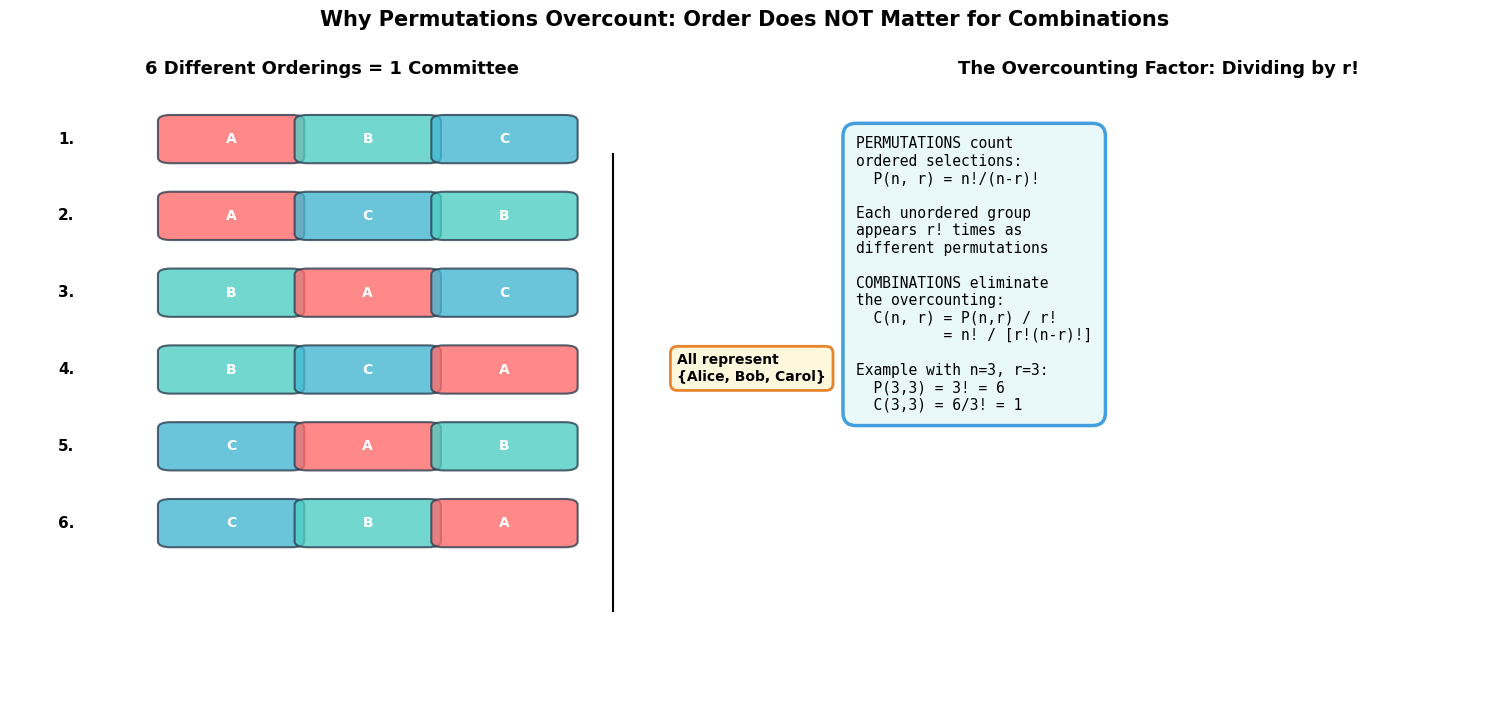

✓ Visual: Why permutations overcount


In [4]:
# Visualize why permutations overcount when order doesn't matter
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Why Permutations Overcount: Order Does NOT Matter for Combinations', 
             fontsize=15, fontweight='bold', y=1.00)

# Left: Show the 6 permutations that map to ONE combination
ax = axes[0]
ax.set_xlim(-1, 3)
ax.set_ylim(-0.8, 7.5)
ax.axis('off')
ax.set_title('6 Different Orderings = 1 Committee', fontsize=13, fontweight='bold', pad=10)

people = ['Alice', 'Bob', 'Carol']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
perms = [
    (people[0], people[1], people[2]),
    (people[0], people[2], people[1]),
    (people[1], people[0], people[2]),
    (people[1], people[2], people[0]),
    (people[2], people[0], people[1]),
    (people[2], people[1], people[0]),
]

for idx, perm in enumerate(perms):
    y = 6.8 - idx * 1.05
    # Number label
    ax.text(-0.7, y, f'{idx+1}.', fontsize=11, fontweight='bold', va='center')
    
    # Person boxes
    for i, p in enumerate(perm):
        rect = patches.FancyBboxPatch((i * 0.85, y - 0.25), 0.75, 0.5,
                                       boxstyle='round,pad=0.08',
                                       facecolor=colors[people.index(p)], 
                                       alpha=0.8,
                                       edgecolor='#2C3E50', linewidth=1.5)
        ax.add_patch(rect)
        ax.text(i * 0.85 + 0.375, y, p[0], ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')

# Add bracket to show they're all the same
ax.plot([2.75, 2.75], [6.6, 0.35], 'k-', linewidth=1.5)
ax.text(3.15, 3.5, 'All represent\n{Alice, Bob, Carol}', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF8DC', 
                  edgecolor='#E67E22', linewidth=2, alpha=0.95))

# Right: Show the overcounting concept
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('The Overcounting Factor: Dividing by r!', fontsize=13, fontweight='bold', pad=10)

text_content = """PERMUTATIONS count
ordered selections:
  P(n, r) = n!/(n-r)!

Each unordered group
appears r! times as
different permutations

COMBINATIONS eliminate
the overcounting:
  C(n, r) = P(n,r) / r!
          = n! / [r!(n-r)!]

Example with n=3, r=3:
  P(3,3) = 3! = 6
  C(3,3) = 6/3! = 1"""

ax.text(0.3, 9.2, text_content, fontsize=10.5, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round,pad=0.9', facecolor='#E8F8F8', edgecolor='#3498DB',
                  linewidth=2.5, alpha=0.92))

plt.tight_layout()
plt.show()

print("✓ Visual: Why permutations overcount")

---
## 2. Deriving the Combination Formula

### Key Insight: Two-Step Counting

Forming an **ordered** selection of $r$ items from $n$ can be broken into two steps:

1. **Choose** which $r$ items to pick (ignoring order) → $C(n, r)$ ways
2. **Arrange** those $r$ items in order → $r!$ ways

By the **product rule**, these two steps together give the total number of ordered selections:

$$P(n, r) = C(n, r) \times r!$$

### Solving for $C(n, r)$

$$C(n, r) = \frac{P(n, r)}{r!}$$

Substituting $P(n, r) = \frac{n!}{(n-r)!}$:

$$C(n, r) = \frac{n!}{r! \times (n-r)!}$$

This is also written as $\binom{n}{r}$ (read "$n$ choose $r$").

### Summary of the Derivation

| Step | What it counts | Formula |
|------|---------------|--------|
| Permutation | Ordered selections of $r$ from $n$ | $P(n, r) = \frac{n!}{(n-r)!}$ |
| Overcount factor | Orderings of $r$ chosen items | $r!$ |
| Combination | Unordered selections of $r$ from $n$ | $C(n, r) = \frac{P(n, r)}{r!} = \frac{n!}{r!(n-r)!}$ |

In [5]:
def P(n, r):
    """Permutations: P(n, r) = n! / (n - r)!"""
    return math.factorial(n) // math.factorial(n - r)

def C(n, r):
    """Combinations: C(n, r) = n! / (r! × (n - r)!)"""
    return math.factorial(n) // (math.factorial(r) * math.factorial(n - r))

# Verify: C(n, r) = P(n, r) / r!
print("n    r    P(n,r)    r!    P(n,r)/r!    C(n,r)    Match?")
print("-" * 58)
for n, r in [(5, 3), (6, 2), (8, 4), (10, 3), (4, 4), (7, 1), (5, 0)]:
    p = P(n, r)
    c = C(n, r)
    ratio = p // math.factorial(r)
    match = "✓" if ratio == c else "✗"
    print(f"{n:<5}{r:<5}{p:<10}{math.factorial(r):<6}{ratio:<13}{c:<10}{match}")

n    r    P(n,r)    r!    P(n,r)/r!    C(n,r)    Match?
----------------------------------------------------------
5    3    60        6     10           10        ✓
6    2    30        2     15           15        ✓
8    4    1680      24    70           70        ✓
10   3    720       6     120          120       ✓
4    4    24        24    1            1         ✓
7    1    7         1     7            7         ✓
5    0    1         1     1            1         ✓


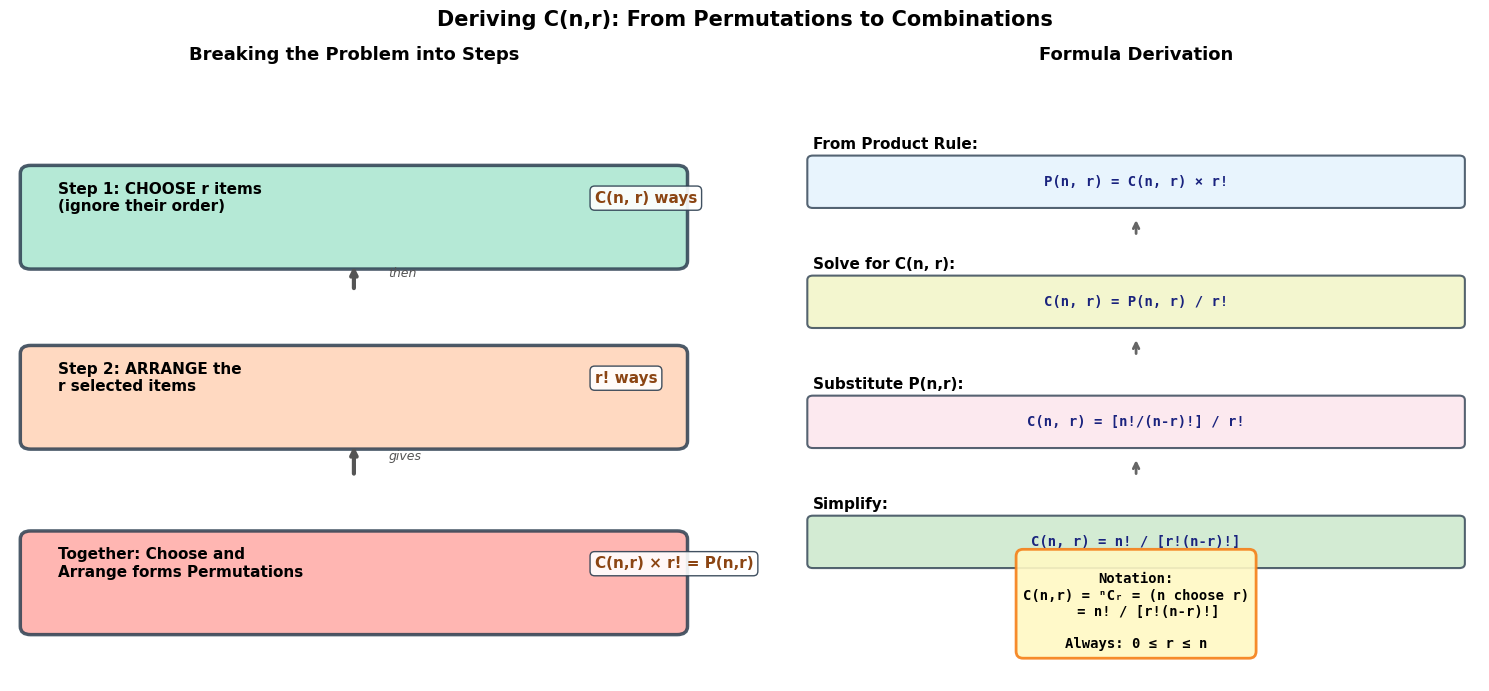

✓ Visual: Formula derivation with improved clarity


In [6]:
# Visualize the formula derivation: Two-step counting process
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Deriving C(n,r): From Permutations to Combinations', 
             fontsize=15, fontweight='bold', y=0.98)

# Left: Two-step process with better visual hierarchy
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 11)
ax.axis('off')
ax.set_title('Breaking the Problem into Steps', fontsize=13, fontweight='bold', pad=15)

# Step boxes with improved styling
steps = [
    {
        'title': 'Step 1: CHOOSE r items\n(ignore their order)',
        'result': 'C(n, r) ways',
        'color': '#A8E6CF',
        'y': 8.5,
        'explanation': 'unordered selection'
    },
    {
        'title': 'Step 2: ARRANGE the\nr selected items',
        'result': 'r! ways',
        'color': '#FFD3B6',
        'y': 5.2,
        'explanation': 'rearrangements'
    },
    {
        'title': 'Together: Choose and\nArrange forms Permutations',
        'result': 'C(n,r) × r! = P(n,r)',
        'color': '#FFAAA5',
        'y': 1.8,
        'explanation': 'ordered selection'
    },
]

for step in steps:
    # Main box
    rect = patches.FancyBboxPatch((0.3, step['y'] - 0.8), 9.4, 1.6,
                                   boxstyle='round,pad=0.15',
                                   facecolor=step['color'], edgecolor='#2C3E50',
                                   linewidth=2.5, alpha=0.85)
    ax.add_patch(rect)
    
    # Title
    ax.text(0.7, step['y'] + 0.35, step['title'], 
            fontsize=11, fontweight='bold', va='center')
    
    # Result/equation
    ax.text(8.5, step['y'] + 0.35, step['result'], 
            fontsize=11, fontweight='bold', va='center',
            color='#8B4513',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                     edgecolor='#2C3E50', linewidth=1, alpha=0.9))

# Arrows between steps
ax.annotate('', xy=(5, 7.65), xytext=(5, 7.15),
            arrowprops=dict(arrowstyle='->', lw=3, color='#555'))
ax.text(5.5, 7.4, 'then', fontsize=9, style='italic', color='#555')

ax.annotate('', xy=(5, 4.35), xytext=(5, 3.75),
            arrowprops=dict(arrowstyle='->', lw=3, color='#555'))
ax.text(5.5, 4.05, 'gives', fontsize=9, style='italic', color='#555')

# Right: Formula derivation with clearer steps
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 11)
ax.axis('off')
ax.set_title('Formula Derivation', fontsize=13, fontweight='bold', pad=15)

formula_lines = [
    ('From Product Rule:', 'P(n, r) = C(n, r) × r!', '#E3F2FD'),
    ('Solve for C(n, r):', 'C(n, r) = P(n, r) / r!', '#F0F4C3'),
    ('Substitute P(n,r):', 'C(n, r) = [n!/(n-r)!] / r!', '#FCE4EC'),
    ('Simplify:', 'C(n, r) = n! / [r!(n-r)!]', '#C8E6C9'),
]

y_start = 9.5
for i, (label, formula, bgcolor) in enumerate(formula_lines):
    y = y_start - i * 2.2
    
    # Label
    ax.text(0.3, y + 0.25, label, fontsize=11, fontweight='bold')
    
    # Formula box
    rect = patches.FancyBboxPatch((0.3, y - 0.75), 9.4, 0.8,
                                   boxstyle='round,pad=0.08',
                                   facecolor=bgcolor, edgecolor='#2C3E50',
                                   linewidth=1.5, alpha=0.8)
    ax.add_patch(rect)
    
    ax.text(5, y - 0.35, formula, ha='center', va='center',
            fontsize=10, fontweight='bold', family='monospace',
            color='#1A237E')
    
    if i < len(formula_lines) - 1:
        ax.annotate('', xy=(5, y - 1.0), xytext=(5, y - 1.35),
                   arrowprops=dict(arrowstyle='->', lw=2, color='#666'))

# Final important note
final_box = """
Notation:
C(n,r) = ⁿCᵣ = (n choose r)
   = n! / [r!(n-r)!]

Always: 0 ≤ r ≤ n"""

ax.text(5, 0.6, final_box, ha='center', fontsize=10, 
        family='monospace', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF9C4',
                 edgecolor='#F57F17', linewidth=2, alpha=0.9))

plt.tight_layout()
plt.show()

print("✓ Visual: Formula derivation with improved clarity")

---
## 3. Examples

### Example 1: Committee Selection

From a club of **10 members**, how many ways can a **committee of 4** be formed?

Order doesn't matter — {A, B, C, D} is the same committee as {D, C, B, A}.

$$C(10, 4) = \frac{10!}{4! \times 6!} = \frac{10 \times 9 \times 8 \times 7}{4 \times 3 \times 2 \times 1} = \frac{5040}{24} = 210$$

In [7]:
n, r = 10, 4
result = C(n, r)

print(f"Club members: {n}")
print(f"Committee size: {r}")
print()
print(f"P({n}, {r}) = {P(n, r)}  (if order mattered)")
print(f"Overcount:   {r}! = {math.factorial(r)}")
print(f"C({n}, {r}) = {P(n, r)} / {math.factorial(r)} = {result}")

Club members: 10
Committee size: 4

P(10, 4) = 5040  (if order mattered)
Overcount:   4! = 24
C(10, 4) = 5040 / 24 = 210


/tmp/ipykernel_285025/2748174783.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/sandeep/workspace/learn-ml/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


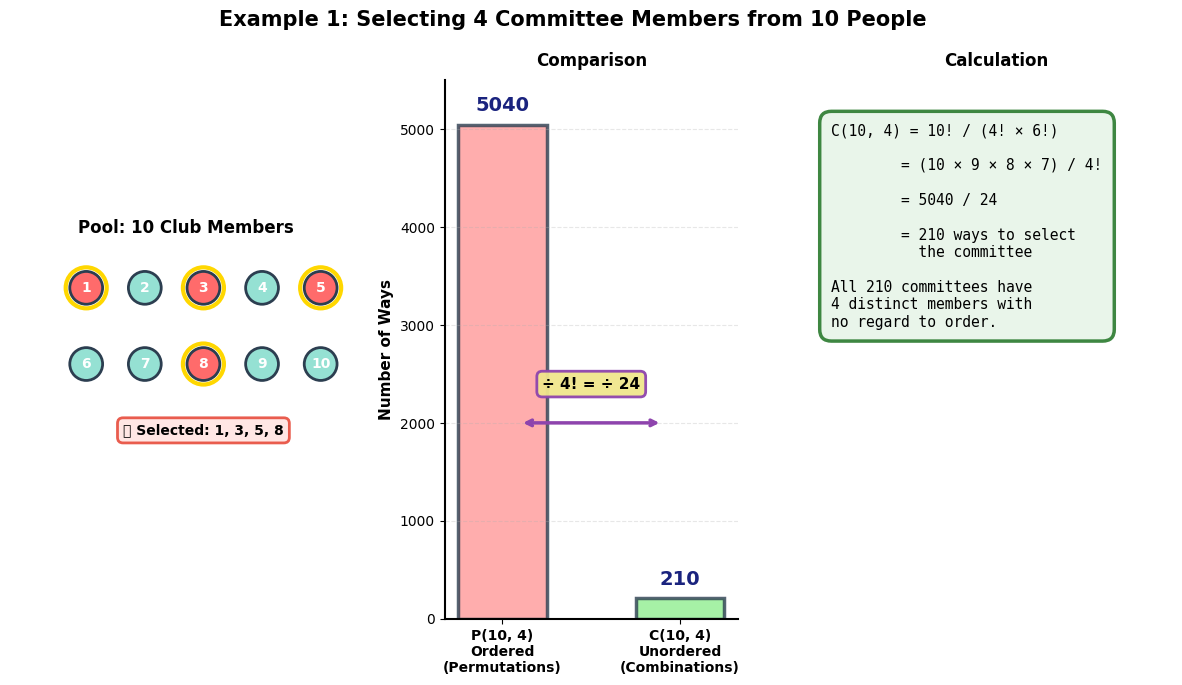

✓ Visual: Committee selection example with enhanced clarity


In [8]:
# Visualize Example 1: Committee Selection (improved)
fig = plt.figure(figsize=(15, 7))
gs = fig.add_gridspec(1, 3, width_ratios=[1.2, 1, 1.2], wspace=0.25)
ax1, ax2, ax3 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])

fig.suptitle('Example 1: Selecting 4 Committee Members from 10 People', 
             fontsize=15, fontweight='bold', y=0.98)

# Left panel: Show all people and highlight selections
ax = ax1
ax.set_xlim(-0.8, 5.2)
ax.set_ylim(-0.5, 3)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Pool: 10 Club Members', fontsize=12, fontweight='bold', pad=10)

# Draw 10 people circles in grid
colors_people = ['#FF6B6B' if i in [0, 2, 4, 7] else '#95E1D3' 
                 for i in range(10)]
for i in range(10):
    x = (i % 5) + 0.5
    y = 2.3 - (i // 5) * 1.3
    
    # Draw circle
    circle = patches.Circle((x, y), 0.28, facecolor=colors_people[i],
                             edgecolor='#2C3E50', linewidth=2)
    ax.add_patch(circle)
    
    # Number inside
    ax.text(x, y, f'{i+1}', ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')
    
    # Highlight selected ones
    if i in [0, 2, 4, 7]:
        ring = patches.Circle((x, y), 0.35, facecolor='none',
                              edgecolor='#FFD700', linewidth=3)
        ax.add_patch(ring)

ax.text(2.5, -0.2, '🔴 Selected: 1, 3, 5, 8', ha='center', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFE4E1', 
                  edgecolor='#E74C3C', linewidth=2, alpha=0.9))

# Middle panel: Comparison bars
ax = ax2
scenarios = ['P(10, 4)\nOrdered\n(Permutations)', 'C(10, 4)\nUnordered\n(Combinations)']
counts = [P(10, 4), C(10, 4)]
colors_bar = ['#FF9999', '#90EE90']

x_pos = np.arange(len(scenarios))
bars = ax.bar(x_pos, counts, color=colors_bar, alpha=0.8, edgecolor='#2C3E50', 
              linewidth=2.5, width=0.5)

# Value labels on bars
for bar, val in zip(bars, counts):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., h + 100, str(int(val)),
            ha='center', va='bottom', fontsize=14, fontweight='bold', color='#1A237E')

ax.set_ylabel('Number of Ways', fontsize=11, fontweight='bold')
ax.set_title('Comparison', fontsize=12, fontweight='bold', pad=10)
ax.set_xticks(x_pos)
ax.set_xticklabels(scenarios, fontsize=10, fontweight='bold')
ax.set_ylim(0, 5500)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)

# Connection arrow and label
ax.annotate('', xy=(0.9, 2000), xytext=(0.1, 2000),
           arrowprops=dict(arrowstyle='<->', lw=2.5, color='#8E44AD'))
ax.text(0.5, 2350, f'÷ 4! = ÷ 24', ha='center', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#F0E68C',
                  edgecolor='#8E44AD', linewidth=2, alpha=0.95))

# Right panel: Calculation breakdown
ax = ax3
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Calculation', fontsize=12, fontweight='bold', pad=10)

calc_text = """C(10, 4) = 10! / (4! × 6!)

        = (10 × 9 × 8 × 7) / 4!
        
        = 5040 / 24
        
        = 210 ways to select
          the committee
          
All 210 committees have
4 distinct members with
no regard to order."""

ax.text(0.3, 9.2, calc_text, fontsize=10.5, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='#E8F5E9', 
                  edgecolor='#2E7D32', linewidth=2.5, alpha=0.92))

plt.tight_layout()
plt.show()

print("✓ Visual: Committee selection example with enhanced clarity")

### Example 2: Lottery Numbers

A lottery draws **6 numbers** from **1 to 49**. Order of the draw doesn't matter.

$$C(49, 6) = \frac{49!}{6! \times 43!}$$

In [9]:
n, r = 49, 6
result = C(n, r)

print(f"Numbers to choose from: 1 to {n}")
print(f"Numbers drawn: {r}")
print(f"C({n}, {r}) = {result:,}")
print()
print(f"Your chance of winning: 1 in {result:,}")
print(f"That's a {1/result:.8f} probability ({1/result*100:.6f}%)")

Numbers to choose from: 1 to 49
Numbers drawn: 6
C(49, 6) = 13,983,816

Your chance of winning: 1 in 13,983,816
That's a 0.00000007 probability (0.000007%)


/tmp/ipykernel_285025/3166598036.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


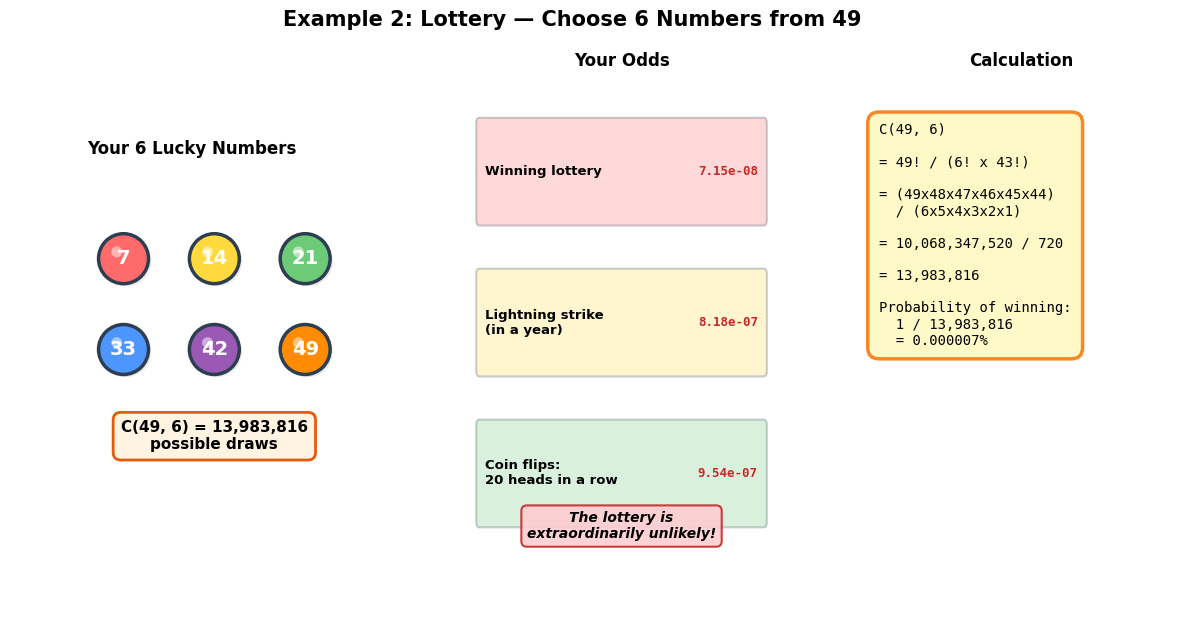

✓ Visual: Lottery example with improved probability context


In [10]:
# Visualize Example 2: Lottery Odds (improved)
fig = plt.figure(figsize=(15, 7))
gs = fig.add_gridspec(1, 3, width_ratios=[1.2, 1, 1], wspace=0.3)
ax1, ax2, ax3 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])

fig.suptitle('Example 2: Lottery — Choose 6 Numbers from 49', 
             fontsize=15, fontweight='bold', y=0.98)

# Left: Lottery ball machine
ax = ax1
ax.set_xlim(-1, 7)
ax.set_ylim(-1, 7)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Your 6 Lucky Numbers', fontsize=12, fontweight='bold', pad=10)

lottery_result = C(49, 6)
lucky_numbers = [7, 14, 21, 33, 42, 49]
colors_balls = ['#FF6B6B', '#FFD93D', '#6BCB77', '#4D96FF', '#9B59B6', '#FF8C00']

# Draw balls in a pattern
positions = [(1.5, 5), (3.5, 5), (5.5, 5), (1.5, 3), (3.5, 3), (5.5, 3)]
for i, ((bx, by), num, col) in enumerate(zip(positions, lucky_numbers, colors_balls)):
    # Shadow
    shadow = patches.Circle((bx + 0.06, by - 0.06), 0.55, facecolor='#CCC', alpha=0.4)
    ax.add_patch(shadow)
    # Ball
    ball = patches.Circle((bx, by), 0.55, facecolor=col, edgecolor='#2C3E50', linewidth=2.5)
    ax.add_patch(ball)
    # Shine highlight
    shine = patches.Circle((bx - 0.15, by + 0.15), 0.12, facecolor='white', alpha=0.5)
    ax.add_patch(shine)
    # Number
    ax.text(bx, by, str(num), ha='center', va='center',
            fontsize=14, fontweight='bold', color='white')

ax.text(3.5, 0.8, f'C(49, 6) = {lottery_result:,}\npossible draws',
        ha='center', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF3E0', 
                  edgecolor='#E65100', linewidth=2, alpha=0.95))

# Middle: Probability scale
ax = ax2
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Your Odds', fontsize=12, fontweight='bold', pad=10)

# Stacked probability comparison
odds_data = [
    ('Winning lottery', 1/lottery_result, '#FF6B6B'),
    ('Lightning strike\n(in a year)', 1/1_222_000, '#FFD93D'),
    ('Coin flips:\n20 heads in a row', 1/1_048_576, '#6BCB77'),
]

for i, (label, prob, color) in enumerate(odds_data):
    y = 8 - i * 2.8
    rect = patches.FancyBboxPatch((0.3, y - 0.6), 9.4, 1.8,
                                   boxstyle='round,pad=0.1',
                                   facecolor=color, edgecolor='#2C3E50',
                                   linewidth=1.5, alpha=0.25)
    ax.add_patch(rect)
    ax.text(0.5, y + 0.3, label, fontsize=9.5, fontweight='bold', va='center')
    ax.text(9.5, y + 0.3, f'{prob:.2e}', fontsize=9, fontweight='bold', 
            va='center', ha='right', family='monospace', color='#C62828')

ax.text(5, 1.5, 'The lottery is\nextraordinarily unlikely!', ha='center',
        fontsize=10, fontweight='bold', style='italic',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFCDD2',
                  edgecolor='#C62828', linewidth=1.5, alpha=0.9))

# Right: Calculation
ax = ax3
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Calculation', fontsize=12, fontweight='bold', pad=10)

calc_text = f"""C(49, 6)

= 49! / (6! x 43!)

= (49x48x47x46x45x44)
  / (6x5x4x3x2x1)

= 10,068,347,520 / 720

= {lottery_result:,}

Probability of winning:
  1 / {lottery_result:,}
  = {1/lottery_result*100:.6f}%"""

ax.text(0.3, 9.2, calc_text, fontsize=10, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='#FFF9C4',
                  edgecolor='#F57F17', linewidth=2.5, alpha=0.92))

plt.tight_layout()
plt.show()

print("✓ Visual: Lottery example with improved probability context")

### Example 3: Handshakes

In a room of **15 people**, everyone shakes hands with everyone else exactly once.

A handshake involves choosing **2 people** from 15 — order doesn't matter (A shaking B's hand = B shaking A's hand).

$$C(15, 2) = \frac{15!}{2! \times 13!} = \frac{15 \times 14}{2} = 105$$

In [11]:
n = 15
r = 2
result = C(n, r)

print(f"People in the room: {n}")
print(f"C({n}, {r}) = ({n} × {n-1}) / {r}! = {n * (n-1)} / {math.factorial(r)} = {result}")
print()
print(f"Total handshakes: {result}")

People in the room: 15
C(15, 2) = (15 × 14) / 2! = 210 / 2 = 105

Total handshakes: 105


/tmp/ipykernel_285025/4175217089.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


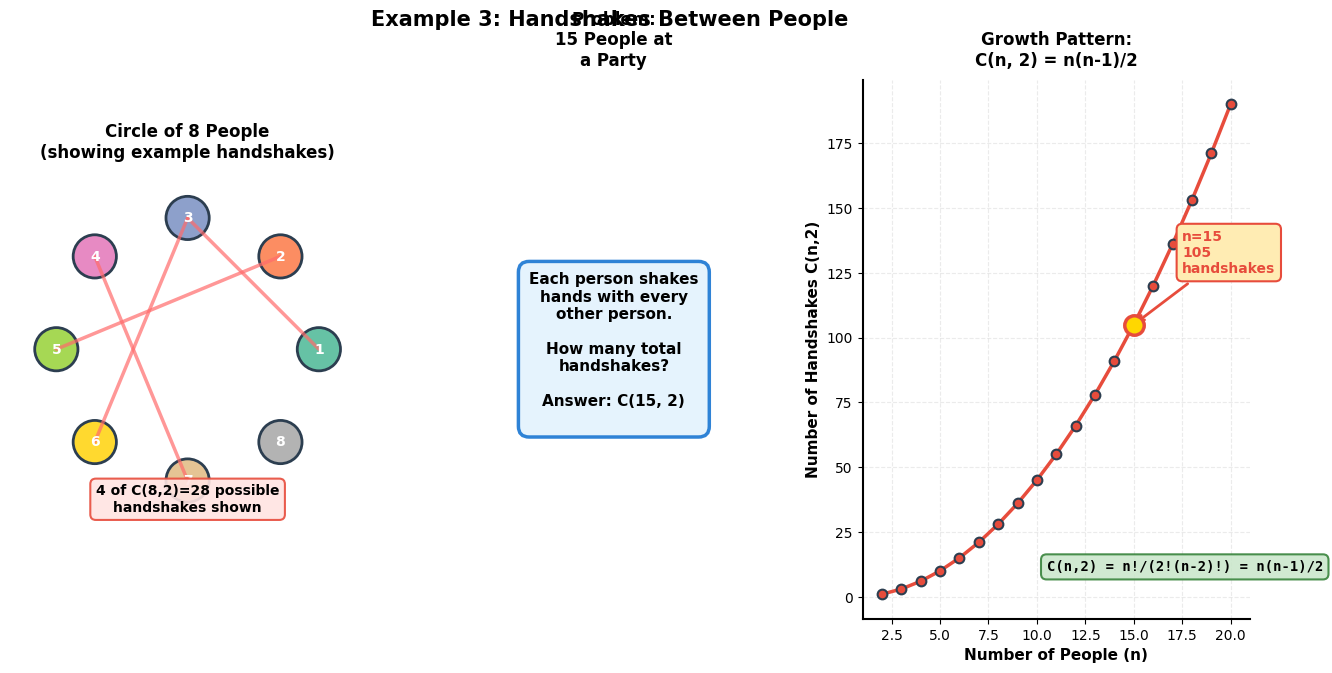

✓ Visual: Handshakes example with improved layout and clarity


In [12]:
# Visualize Example 3: Handshakes (improved)
fig = plt.figure(figsize=(16, 7))
gs = fig.add_gridspec(1, 3, width_ratios=[1.1, 0.9, 1.2], wspace=0.3)
ax1, ax2, ax3 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])

fig.suptitle('Example 3: Handshakes Between People', 
             fontsize=15, fontweight='bold', y=0.98)

# Left: Network graph of handshakes
ax = ax1
ax.set_xlim(-2.3, 2.3)
ax.set_ylim(-2.3, 2.3)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Circle of 8 People\n(showing example handshakes)', fontsize=12, fontweight='bold', pad=10)

# Draw circle of people
n_shown = 8
angles = np.linspace(0, 2 * np.pi, n_shown, endpoint=False)
radius = 1.7

colors_circ = plt.cm.Set2(np.linspace(0, 1, n_shown))
points = []
for i, angle in enumerate(angles):
    x = radius * np.cos(angle)
    y = radius * np.sin(angle)
    points.append((x, y))
    
    # Person circle
    circle = patches.Circle((x, y), 0.28, facecolor=colors_circ[i],
                             edgecolor='#2C3E50', linewidth=2)
    ax.add_patch(circle)
    
    ax.text(x, y, f'{i+1}', ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')

# Draw example handshake lines
handshake_pairs = [(0, 2), (1, 4), (3, 6), (2, 5)]
for i, j in handshake_pairs:
    x1, y1 = points[i]
    x2, y2 = points[j]
    ax.plot([x1, x2], [y1, y2], color='#FF6B6B', linewidth=2.5, alpha=0.7, 
            linestyle='-', solid_capstyle='round')

ax.text(0, -2.1, f'{len(handshake_pairs)} of C(8,2)={C(8,2)} possible\nhandshakes shown', 
        ha='center', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFE4E1',
                  edgecolor='#E74C3C', linewidth=1.5, alpha=0.9))

# Middle: Problem for n=15
ax = ax2
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Problem:\n15 People at\na Party', fontsize=12, fontweight='bold', pad=10)

handshake_calc = """Each person shakes
hands with every
other person.

How many total
handshakes?

Answer: C(15, 2)
"""

ax.text(5, 5, handshake_calc, ha='center', va='center', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.7', facecolor='#E3F2FD',
                  edgecolor='#1976D2', linewidth=2.5, alpha=0.9))

# Right: Growth pattern and calculation
ax = ax3

# Growth graph
group_sizes = np.arange(2, 21)
handshakes = [C(n, 2) for n in group_sizes]

ax.plot(group_sizes, handshakes, 'o-', linewidth=2.5, markersize=7,
        color='#E74C3C', markeredgecolor='#2C3E50', markeredgewidth=1.5)

# Highlight n=15
idx_15 = np.where(group_sizes == 15)[0][0]
ax.plot(15, handshakes[idx_15], 'o', markersize=14, color='#FFD700',
        markeredgecolor='#E74C3C', markeredgewidth=2.5, zorder=5)

# Arrow and value label
ax.annotate(f'n=15\n{handshakes[idx_15]}\nhandshakes',
            xy=(15, handshakes[idx_15]), xytext=(17.5, handshakes[idx_15] + 20),
            fontsize=10, fontweight='bold', color='#E74C3C',
            arrowprops=dict(arrowstyle='->', lw=2, color='#E74C3C'),
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFECB3',
                     edgecolor='#E74C3C', linewidth=1.5))

ax.set_xlabel('Number of People (n)', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Handshakes C(n,2)', fontsize=11, fontweight='bold')
ax.set_title('Growth Pattern:\nC(n, 2) = n(n-1)/2', fontsize=12, fontweight='bold', pad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.8)
ax.set_xlim(1, 21)

# Add formula annotation
formula_text = "C(n,2) = n!/(2!(n-2)!) = n(n-1)/2"
ax.text(10.5, 10, formula_text, fontsize=10, fontweight='bold', family='monospace',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#C8E6C9',
                 edgecolor='#2E7D32', linewidth=1.5, alpha=0.85))

plt.tight_layout()
plt.show()

print("✓ Visual: Handshakes example with improved layout and clarity")

### Example 4: Choosing a Hand of Cards

A standard deck has **52 cards**. A poker hand has **5 cards**.

$$C(52, 5) = \frac{52!}{5! \times 47!}$$

In [13]:
n, r = 52, 5
result = C(n, r)

print(f"Cards in deck: {n}")
print(f"Hand size: {r}")
print(f"C({n}, {r}) = {result:,}")
print()
print(f"Compare with ordered selections: P({n}, {r}) = {P(n, r):,}")
print(f"Overcount factor: {r}! = {math.factorial(r)}")

Cards in deck: 52
Hand size: 5
C(52, 5) = 2,598,960

Compare with ordered selections: P(52, 5) = 311,875,200
Overcount factor: 5! = 120


/tmp/ipykernel_285025/3198215053.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


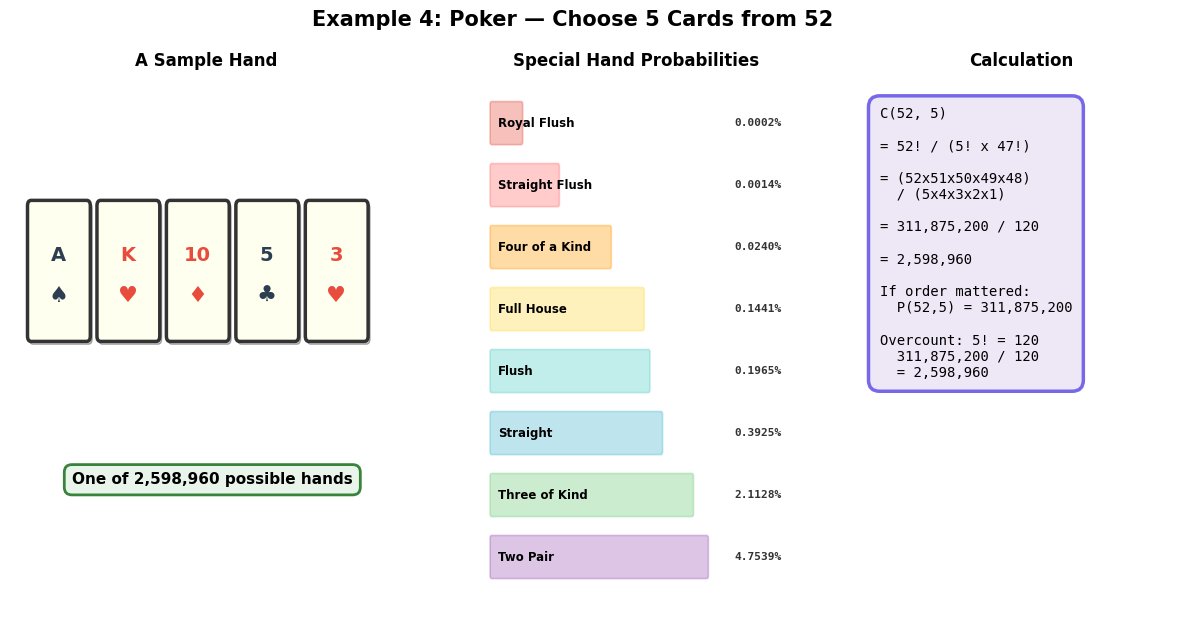

✓ Visual: Poker cards example with hand probabilities


In [14]:
# Visualize Example 4: Poker Hand Combinations (improved)
fig = plt.figure(figsize=(15, 7))
gs = fig.add_gridspec(1, 3, width_ratios=[1.3, 1, 1], wspace=0.25)
ax1, ax2, ax3 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])

fig.suptitle('Example 4: Poker — Choose 5 Cards from 52', 
             fontsize=15, fontweight='bold', y=0.98)

# Left: Show sample poker hand with larger cards
ax = ax1
ax.set_xlim(-0.5, 6)
ax.set_ylim(-1, 5)
ax.axis('off')
ax.set_title('A Sample Hand', fontsize=12, fontweight='bold', pad=10)

suit_colors = {'♠': '#2C3E50', '♥': '#E74C3C', '♦': '#E74C3C', '♣': '#2C3E50'}
example_cards = [('A', '♠'), ('K', '♥'), ('10', '♦'), ('5', '♣'), ('3', '♥')]

for i, (rank, suit) in enumerate(example_cards):
    x = i * 1.15 + 0.3
    y = 2.8
    # Card shadow
    shadow = patches.FancyBboxPatch((x - 0.42, y - 0.68), 0.92, 1.45,
                                     boxstyle='round,pad=0.06',
                                     facecolor='#BBB', alpha=0.35)
    ax.add_patch(shadow)
    # Card
    rect = patches.FancyBboxPatch((x - 0.45, y - 0.65), 0.92, 1.45,
                                   boxstyle='round,pad=0.06',
                                   facecolor='#FFFFF0', edgecolor='#333',
                                   linewidth=2.5)
    ax.add_patch(rect)
    # Rank and suit
    ax.text(x, y + 0.25, rank, ha='center', va='center',
            fontsize=14, fontweight='bold', color=suit_colors[suit])
    ax.text(x, y - 0.2, suit, ha='center', va='center',
            fontsize=16, color=suit_colors[suit])

ax.text(2.85, 0.5, f'One of {C(52,5):,} possible hands',
        ha='center', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#E8F5E9', 
                  edgecolor='#2E7D32', linewidth=2, alpha=0.95))

# Middle: Special hand probabilities
ax = ax2
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Special Hand Probabilities', fontsize=12, fontweight='bold', pad=10)

total_hands = C(52, 5)
hand_types = [
    ('Royal Flush', 4, '#E74C3C'),
    ('Straight Flush', 36, '#FF6B6B'),
    ('Four of a Kind', 624, '#FF9800'),
    ('Full House', 3744, '#FFD93D'),
    ('Flush', 5108, '#4ECDC4'),
    ('Straight', 10200, '#45B7D1'),
    ('Three of Kind', 54912, '#6BCB77'),
    ('Two Pair', 123552, '#9B59B6'),
]

for i, (name, count, color) in enumerate(hand_types):
    y_pos = 9.2 - i * 1.15
    prob = count / total_hands
    # Color bar proportional to log-probability
    bar_w = max(0.3, min(8, np.log10(count + 1) * 1.4))
    rect = patches.FancyBboxPatch((0.2, y_pos - 0.35), bar_w, 0.7,
                                   boxstyle='round,pad=0.05',
                                   facecolor=color, alpha=0.35,
                                   edgecolor=color, linewidth=1.2)
    ax.add_patch(rect)
    ax.text(0.4, y_pos, name, fontsize=8.5, fontweight='bold', va='center')
    ax.text(9.8, y_pos, f'{prob:.4%}', fontsize=8, va='center', ha='right',
            family='monospace', fontweight='bold', color='#333')

# Right: Calculation breakdown
ax = ax3
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Calculation', fontsize=12, fontweight='bold', pad=10)

calc_text = f"""C(52, 5)

= 52! / (5! x 47!)

= (52x51x50x49x48)
  / (5x4x3x2x1)

= 311,875,200 / 120

= {C(52,5):,}

If order mattered:
  P(52,5) = {P(52,5):,}

Overcount: 5! = {math.factorial(5)}
  {P(52,5):,} / 120
  = {C(52,5):,}"""

ax.text(0.3, 9.5, calc_text, fontsize=10, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='#EDE7F6',
                  edgecolor='#6c5ce7', linewidth=2.5, alpha=0.92))

plt.tight_layout()
plt.show()

print("✓ Visual: Poker cards example with hand probabilities")

---
## 4. Properties of Combinations

### Property 1: Symmetry

$$C(n, r) = C(n, n - r)$$

**Why?** Choosing $r$ items to **include** is the same as choosing $n - r$ items to **exclude**.

From the formula: $\frac{n!}{r!(n-r)!} = \frac{n!}{(n-r)!r!}$ — just swap $r$ and $n-r$.

In [15]:
# Verify symmetry
print("n    r    C(n,r)    C(n,n-r)    Equal?")
print("-" * 44)
for n, r in [(10, 3), (8, 2), (6, 4), (52, 5), (20, 17)]:
    c1 = C(n, r)
    c2 = C(n, n - r)
    eq = "✓" if c1 == c2 else "✗"
    print(f"{n:<5}{r:<5}{c1:<10}{c2:<12}{eq}")

print()
print("C(52, 5) = C(52, 47) — choosing 5 cards to keep = choosing 47 to leave")

n    r    C(n,r)    C(n,n-r)    Equal?
--------------------------------------------
10   3    120       120         ✓
8    2    28        28          ✓
6    4    15        15          ✓
52   5    2598960   2598960     ✓
20   17   1140      1140        ✓

C(52, 5) = C(52, 47) — choosing 5 cards to keep = choosing 47 to leave


### Property 2: Pascal's Identity

$$C(n, r) = C(n-1, r-1) + C(n-1, r)$$

**Why?** Consider a specific item $x$. Every combination either:
- **Includes** $x$ → then choose remaining $r-1$ from the other $n-1$ items → $C(n-1, r-1)$
- **Excludes** $x$ → then choose all $r$ from the other $n-1$ items → $C(n-1, r)$

By the **sum rule** (two mutually exclusive cases): $C(n, r) = C(n-1, r-1) + C(n-1, r)$

In [16]:
# Verify Pascal's Identity
print("n    r    C(n,r)    C(n-1,r-1) + C(n-1,r)    Match?")
print("-" * 54)
for n, r in [(5, 2), (8, 3), (10, 4), (6, 1), (7, 5)]:
    lhs = C(n, r)
    rhs = C(n - 1, r - 1) + C(n - 1, r)
    match = "✓" if lhs == rhs else "✗"
    print(f"{n:<5}{r:<5}{lhs:<10}{C(n-1, r-1)} + {C(n-1, r)} = {rhs:<14}{match}")

n    r    C(n,r)    C(n-1,r-1) + C(n-1,r)    Match?
------------------------------------------------------
5    2    10        4 + 6 = 10            ✓
8    3    56        21 + 35 = 56            ✓
10   4    210       84 + 126 = 210           ✓
6    1    6         1 + 5 = 6             ✓
7    5    21        15 + 6 = 21            ✓


### Property 3: Pascal's Triangle

Pascal's Identity leads to **Pascal's Triangle**, where each entry is the sum of the two entries above it.

Row $n$, position $r$ contains $C(n, r)$.

In [17]:
# Build Pascal's Triangle
rows = 8

print("Pascal's Triangle (rows 0-7):")
print()
for n in range(rows):
    values = []
    for r in range(n + 1):
        values.append(str(C(n, r)))
    row_str = "  ".join(values)
    padding = "   " * (rows - n - 1)
    print(f"{padding}{row_str}")

Pascal's Triangle (rows 0-7):

                     1
                  1  1
               1  2  1
            1  3  3  1
         1  4  6  4  1
      1  5  10  10  5  1
   1  6  15  20  15  6  1
1  7  21  35  35  21  7  1


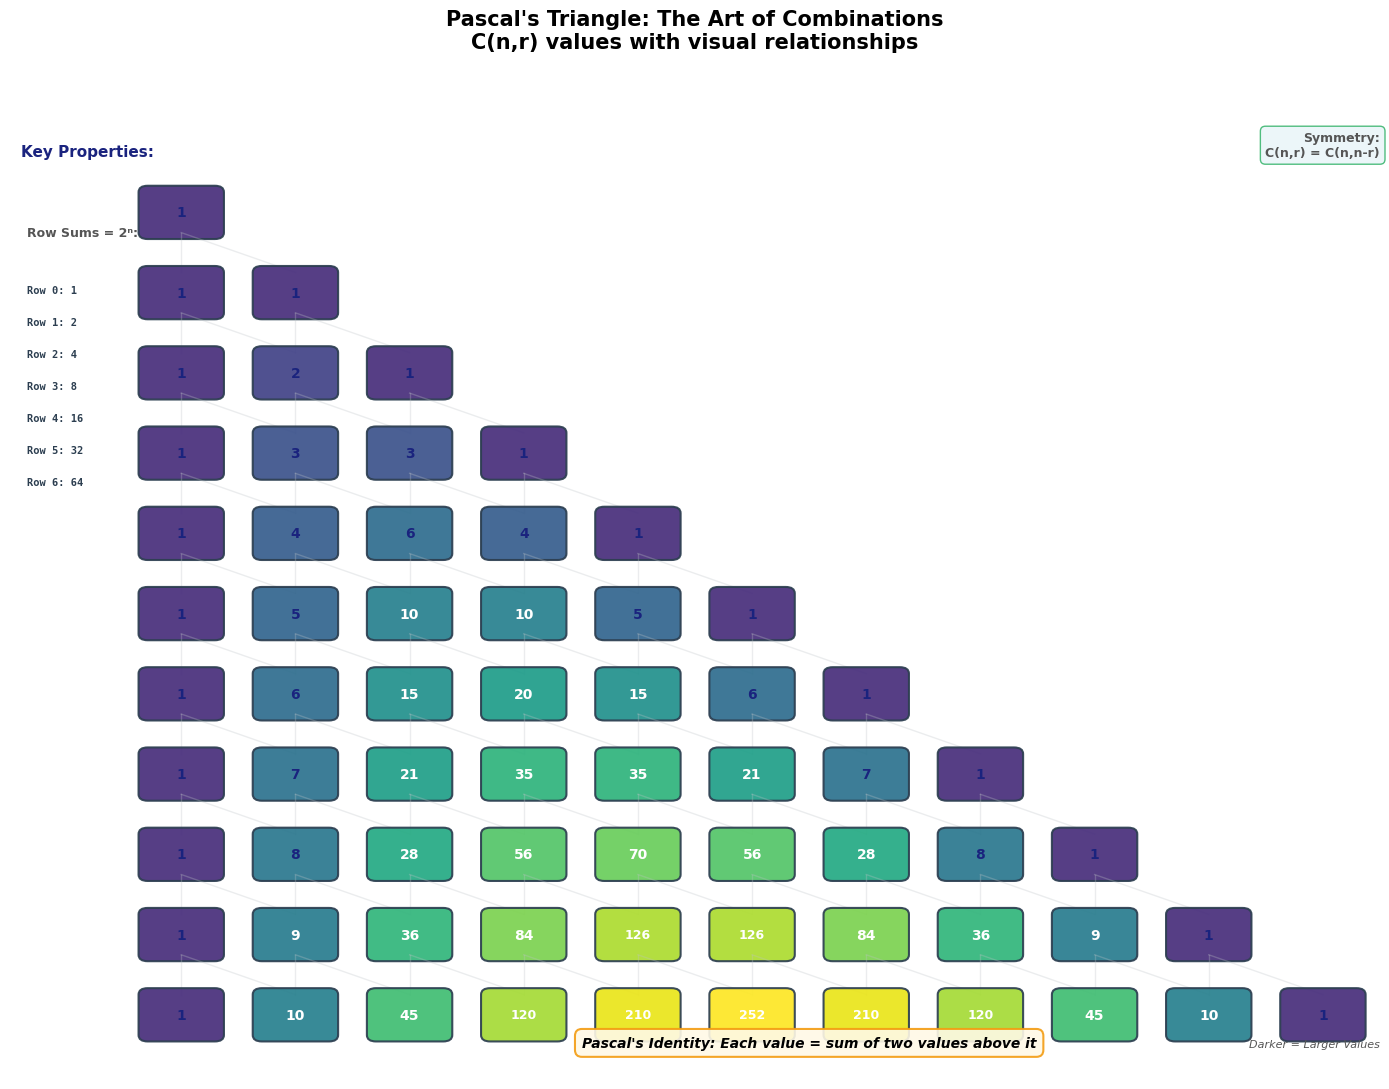

✓ Visual: Enhanced Pascal's Triangle with connections and properties


In [18]:
# Visualize Pascal's Triangle with enhanced colors and properties
fig = plt.figure(figsize=(14, 11))
ax = plt.subplot(111)

rows = 11
triangle_data = []
for n in range(rows):
    row = [C(n, r) for r in range(n + 1)]
    triangle_data.append(row)

# Create color map based on values
max_val = max(max(row) for row in triangle_data)
colors_map = plt.cm.viridis

ax.set_xlim(-1.5, rows - 0.5)
ax.set_ylim(-1, rows + 0.5)
ax.axis('off')
ax.set_title("Pascal's Triangle: The Art of Combinations\nC(n,r) values with visual relationships", 
             fontsize=15, fontweight='bold', pad=20)

# Draw triangle cells
for n, row in enumerate(triangle_data):
    for r, val in enumerate(row):
        # Position (centered)
        x = n / 2.0 + r - n / 2.0
        y = rows - n - 1.2
        
        # Color based on value (using log scale)
        color_intensity = np.log10(val + 1) / np.log10(max_val + 1)
        color = colors_map(color_intensity)
        
        # Cell (rounded rectangle instead of circle for more visual interest)
        cell_size = 0.42
        rect = patches.FancyBboxPatch((x - cell_size * 0.7, y - cell_size * 0.6), 
                                       cell_size * 1.4, cell_size * 1.2,
                                       boxstyle='round,pad=0.08',
                                       facecolor=color, edgecolor='#2C3E50', 
                                       linewidth=1.5, alpha=0.92)
        ax.add_patch(rect)
        
        # Value text (color-coded for readability)
        if val < 100:
            text_display = f'{val}'
            fontsize = 10
        elif val < 1000:
            text_display = f'{val}'
            fontsize = 9
        else:
            text_display = f'{val}'
            fontsize = 8
        
        text_color = 'white' if color_intensity > 0.4 else '#1A237E'
        ax.text(x, y, text_display, ha='center', va='center',
                fontsize=fontsize, fontweight='bold', color=text_color)
        
        # Draw connections to child nodes (sum property)
        if n < rows - 1:
            x_left = (n + 1) / 2.0 + r - (n + 1) / 2.0
            x_right = (n + 1) / 2.0 + (r + 1) - (n + 1) / 2.0
            y_below = rows - (n + 1) - 1.2
            
            # Connection lines (subtle)
            ax.plot([x, x_left], [y - cell_size * 0.6, y_below + cell_size * 0.6],
                   color='#BDC3C7', alpha=0.3, linewidth=1, zorder=1)
            ax.plot([x, x_right], [y - cell_size * 0.6, y_below + cell_size * 0.6],
                   color='#BDC3C7', alpha=0.3, linewidth=1, zorder=1)

# Add property annotations on the left
ax.text(-1.4, rows - 0.5, 'Key Properties:', fontsize=11, fontweight='bold', color='#1A237E')

# Row sums annotation
ax.text(-1.35, rows - 1.5, 'Row Sums = 2ⁿ:', fontsize=9, fontweight='bold', color='#555')
for n in range(min(7, rows)):
    row_sum = 2 ** n
    ax.text(-1.35, rows - 2.2 - n * 0.4, f'Row {n}: {row_sum}',
           fontsize=7.5, color='#2C3E50', family='monospace', fontweight='bold')

# Symmetry annotation on the right
ax.text(rows - 0.5, rows - 0.5, 'Symmetry:\nC(n,r) = C(n,n-r)', 
        fontsize=9, fontweight='bold', color='#555',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#E8F4F8', 
                 edgecolor='#27AE60', linewidth=1, alpha=0.8),
        ha='right')

# Add Pascal's Identity note
ax.text(rows / 2, -0.6, "Pascal's Identity: Each value = sum of two values above it",
       ha='center', fontsize=10, fontweight='bold', style='italic',
       bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF9E6',
                edgecolor='#F39C12', linewidth=1.5, alpha=0.9))

# Color legend (simplified)
ax.text(rows - 0.5, -0.6, 'Darker = Larger Values', fontsize=8, color='#555', ha='right', style='italic')

plt.tight_layout()
plt.show()

print("✓ Visual: Enhanced Pascal's Triangle with connections and properties")

### Property 4: Sum of a Row

$$\sum_{r=0}^{n} C(n, r) = 2^n$$

**Why?** Each of the $n$ items is either **included** or **excluded** — 2 choices per item, by the **product rule**: $2^n$ subsets total. The left side counts those subsets grouped by size.

In [19]:
# Verify sum of each row = 2^n
print("n    Sum of C(n,0) + C(n,1) + ... + C(n,n)    2^n    Match?")
print("-" * 62)
for n in range(9):
    row_sum = 0
    for r in range(n + 1):
        row_sum += C(n, r)
    power = 2 ** n
    match = "✓" if row_sum == power else "✗"
    print(f"{n:<5}{row_sum:<44}{power:<7}{match}")

n    Sum of C(n,0) + C(n,1) + ... + C(n,n)    2^n    Match?
--------------------------------------------------------------
0    1                                           1      ✓
1    2                                           2      ✓
2    4                                           4      ✓
3    8                                           8      ✓
4    16                                          16     ✓
5    32                                          32     ✓
6    64                                          64     ✓
7    128                                         128    ✓
8    256                                         256    ✓


/tmp/ipykernel_285025/1391533117.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/sandeep/workspace/learn-ml/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8306 (\u2072) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sandeep/workspace/learn-ml/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8307 (\u2073) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


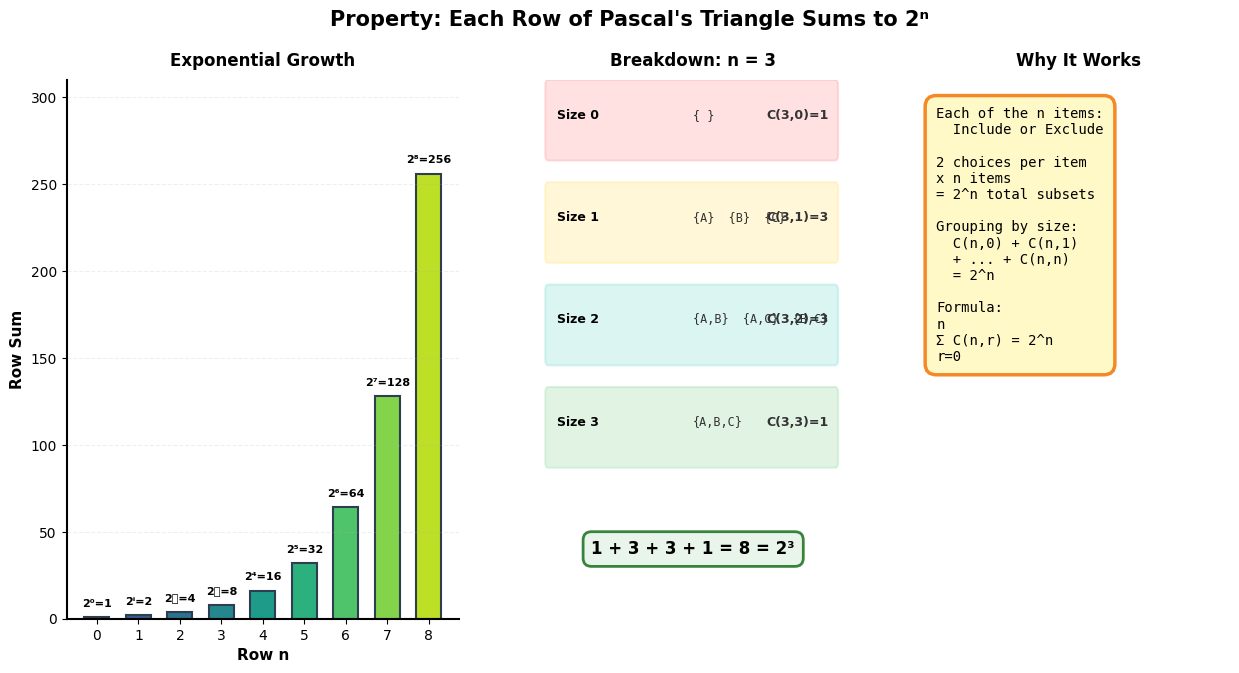

✓ Visual: Row sum = 2^n with breakdown and proof


In [20]:
# Visualize the sum of a row = 2^n property (improved)
fig = plt.figure(figsize=(15, 7))
gs = fig.add_gridspec(1, 3, width_ratios=[1.3, 1, 1], wspace=0.25)
ax1, ax2, ax3 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])

fig.suptitle('Property: Each Row of Pascal\'s Triangle Sums to 2ⁿ',
             fontsize=15, fontweight='bold', y=0.98)

# Left: Gradient bar chart with exponential growth
ax = ax1
n_vals = list(range(9))
row_sums = [2 ** n for n in n_vals]
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(n_vals)))

bars = ax.bar(n_vals, row_sums, color=colors, edgecolor='#2C3E50', linewidth=1.5, width=0.6)

for bar, val, n in zip(bars, row_sums, n_vals):
    h = bar.get_height()
    label = f'2{chr(0x2070+n) if n < 4 else "⁴⁵⁶⁷⁸"[n-4]}={val}' if n > 0 else f'2⁰=1'
    ax.text(bar.get_x() + bar.get_width() / 2., h + 5, label,
            ha='center', va='bottom', fontsize=8, fontweight='bold', rotation=0)

ax.set_xlabel('Row n', fontsize=11, fontweight='bold')
ax.set_ylabel('Row Sum', fontsize=11, fontweight='bold')
ax.set_title('Exponential Growth', fontsize=12, fontweight='bold', pad=10)
ax.set_xticks(n_vals)
ax.set_ylim(0, 310)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.grid(axis='y', alpha=0.2, linestyle='--')

# Middle: Visual breakdown for n=3
ax = ax2
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Breakdown: n = 3', fontsize=12, fontweight='bold', pad=10)

subsets = [
    ('Size 0', ['{ }'], 'C(3,0)=1', '#FF6B6B'),
    ('Size 1', ['{A}', '{B}', '{C}'], 'C(3,1)=3', '#FFD93D'),
    ('Size 2', ['{A,B}', '{A,C}', '{B,C}'], 'C(3,2)=3', '#4ECDC4'),
    ('Size 3', ['{A,B,C}'], 'C(3,3)=1', '#6BCB77'),
]

y = 9.2
for label, items, formula, color in subsets:
    rect = patches.FancyBboxPatch((0.2, y - 0.6), 9.5, 1.3,
                                   boxstyle='round,pad=0.1',
                                   facecolor=color, alpha=0.2,
                                   edgecolor=color, linewidth=1.5)
    ax.add_patch(rect)
    ax.text(0.5, y + 0.15, label, fontsize=9, fontweight='bold', va='center')
    ax.text(5, y + 0.15, '  '.join(items), fontsize=8.5, va='center',
            family='monospace', color='#333')
    ax.text(9.5, y + 0.15, formula, fontsize=9, fontweight='bold', va='center',
            ha='right', color='#333')
    y -= 1.9

# Sum line
ax.text(5, 1.2, '1 + 3 + 3 + 1 = 8 = 2³',
        ha='center', fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#E8F5E9',
                  edgecolor='#2E7D32', linewidth=2, alpha=0.95))

# Right: Why?
ax = ax3
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Why It Works', fontsize=12, fontweight='bold', pad=10)

why_text = """Each of the n items:
  Include or Exclude

2 choices per item
x n items
= 2^n total subsets

Grouping by size:
  C(n,0) + C(n,1)
  + ... + C(n,n)
  = 2^n

Formula:
n
Σ C(n,r) = 2^n
r=0"""

ax.text(0.3, 9.5, why_text, fontsize=10, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='#FFF9C4',
                  edgecolor='#F57F17', linewidth=2.5, alpha=0.92))

plt.tight_layout()
plt.show()

print("✓ Visual: Row sum = 2^n with breakdown and proof")

### Property 5: Special Cases

- $C(n, 0) = 1$ — one way to choose nothing (the empty set)
- $C(n, 1) = n$ — choosing 1 item from $n$
- $C(n, n) = 1$ — one way to choose everything
- $C(n, 2) = \frac{n(n-1)}{2}$ — number of pairs

In [21]:
print("Special cases:")
print()
for n in [5, 8, 10, 20]:
    print(f"n = {n:>2}:  C(n,0) = {C(n,0)},  C(n,1) = {C(n,1):>2},  C(n,2) = {C(n,2):>3},  C(n,n) = {C(n,n)}")

Special cases:

n =  5:  C(n,0) = 1,  C(n,1) =  5,  C(n,2) =  10,  C(n,n) = 1
n =  8:  C(n,0) = 1,  C(n,1) =  8,  C(n,2) =  28,  C(n,n) = 1
n = 10:  C(n,0) = 1,  C(n,1) = 10,  C(n,2) =  45,  C(n,n) = 1
n = 20:  C(n,0) = 1,  C(n,1) = 20,  C(n,2) = 190,  C(n,n) = 1


---
## 5. Combining Combinations with Product and Sum Rules

### Example 5: Mixed Committee

A department has **8 men** and **5 women**. Form a committee of **5** that must have **exactly 3 men and 2 women**.

- Choose 3 men from 8: $C(8, 3)$
- Choose 2 women from 5: $C(5, 2)$

By the **product rule** (we need men AND women):

$$C(8, 3) \times C(5, 2) = 56 \times 10 = 560$$

In [22]:
men = 8
women = 5
choose_men = 3
choose_women = 2

ways_men = C(men, choose_men)
ways_women = C(women, choose_women)
total = ways_men * ways_women

print(f"Choose {choose_men} men from {men}: C({men}, {choose_men}) = {ways_men}")
print(f"Choose {choose_women} women from {women}: C({women}, {choose_women}) = {ways_women}")
print(f"Total (product rule): {ways_men} × {ways_women} = {total}")

Choose 3 men from 8: C(8, 3) = 56
Choose 2 women from 5: C(5, 2) = 10
Total (product rule): 56 × 10 = 560


/tmp/ipykernel_285025/434767104.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


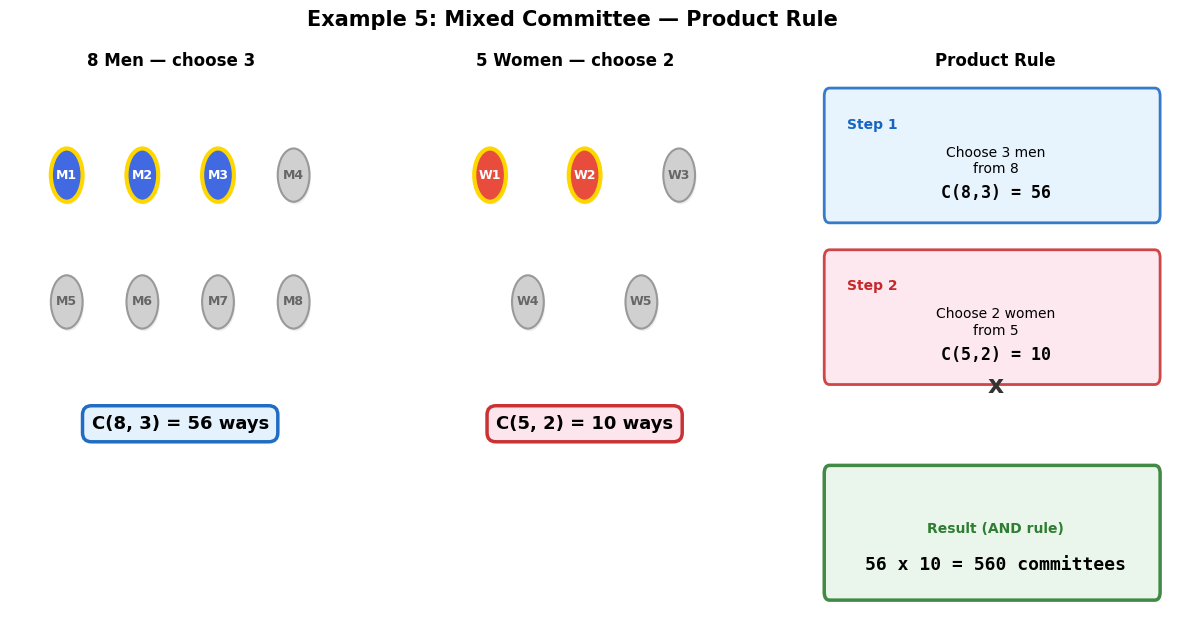

✓ Visual: Mixed committee (product rule)


In [23]:
# Visualize Example 5: Mixed Committee (Product Rule) — improved
fig = plt.figure(figsize=(15, 7))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.1], wspace=0.25)
ax1, ax2, ax3 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])

fig.suptitle('Example 5: Mixed Committee — Product Rule',
             fontsize=15, fontweight='bold', y=0.98)

# Left: 8 Men — choose 3
ax = ax1
ax.set_xlim(-0.5, 8)
ax.set_ylim(-0.5, 8)
ax.axis('off')
ax.set_title('8 Men — choose 3', fontsize=12, fontweight='bold', pad=10)

men_positions = [(1, 6.5), (3, 6.5), (5, 6.5), (7, 6.5),
                 (1, 4.5), (3, 4.5), (5, 4.5), (7, 4.5)]
for i, (mx, my) in enumerate(men_positions):
    selected = i < 3
    fc = '#4169E1' if selected else '#D0D0D0'
    ec = '#FFD700' if selected else '#999'
    lw = 3 if selected else 1.5
    # Shadow
    ax.add_patch(patches.Circle((mx + 0.04, my - 0.04), 0.42, facecolor='#BBB', alpha=0.25))
    ax.add_patch(patches.Circle((mx, my), 0.42, facecolor=fc, edgecolor=ec, linewidth=lw))
    ax.text(mx, my, f'M{i+1}', ha='center', va='center',
            fontsize=9, fontweight='bold', color='white' if selected else '#666')

ax.text(4, 2.5, f'C(8, 3) = {C(8,3)} ways', ha='center', fontsize=13, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#E3F2FD',
                  edgecolor='#1565C0', linewidth=2.5, alpha=0.95))

# Middle: 5 Women — choose 2
ax = ax2
ax.set_xlim(-0.5, 8)
ax.set_ylim(-0.5, 8)
ax.axis('off')
ax.set_title('5 Women — choose 2', fontsize=12, fontweight='bold', pad=10)

women_positions = [(1.5, 6.5), (4, 6.5), (6.5, 6.5),
                   (2.5, 4.5), (5.5, 4.5)]
for i, (wx, wy) in enumerate(women_positions):
    selected = i < 2
    fc = '#E74C3C' if selected else '#D0D0D0'
    ec = '#FFD700' if selected else '#999'
    lw = 3 if selected else 1.5
    ax.add_patch(patches.Circle((wx + 0.04, wy - 0.04), 0.42, facecolor='#BBB', alpha=0.25))
    ax.add_patch(patches.Circle((wx, wy), 0.42, facecolor=fc, edgecolor=ec, linewidth=lw))
    ax.text(wx, wy, f'W{i+1}', ha='center', va='center',
            fontsize=9, fontweight='bold', color='white' if selected else '#666')

ax.text(4, 2.5, f'C(5, 2) = {C(5,2)} ways', ha='center', fontsize=13, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FCE4EC',
                  edgecolor='#C62828', linewidth=2.5, alpha=0.95))

# Right: Product rule
ax = ax3
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Product Rule', fontsize=12, fontweight='bold', pad=10)

# Step boxes
steps = [
    ('Step 1', 'Choose 3 men\nfrom 8', f'C(8,3) = {C(8,3)}', '#E3F2FD', '#1565C0'),
    ('Step 2', 'Choose 2 women\nfrom 5', f'C(5,2) = {C(5,2)}', '#FCE4EC', '#C62828'),
]

for i, (step_label, desc, formula, bg, ec) in enumerate(steps):
    y = 8.5 - i * 3
    rect = patches.FancyBboxPatch((0.3, y - 1), 9.2, 2.2,
                                   boxstyle='round,pad=0.15',
                                   facecolor=bg, edgecolor=ec,
                                   linewidth=2, alpha=0.85)
    ax.add_patch(rect)
    ax.text(0.8, y + 0.6, step_label, fontsize=10, fontweight='bold', color=ec)
    ax.text(5, y, desc, fontsize=10, ha='center', va='center')
    ax.text(5, y - 0.6, formula, fontsize=12, ha='center', va='center',
            fontweight='bold', family='monospace')

# Multiplication arrow
ax.text(5, 4.2, 'x', fontsize=18, ha='center', fontweight='bold', color='#333')

# Result
result_text = f'{C(8,3)} x {C(5,2)} = {C(8,3)*C(5,2)} committees'
rect = patches.FancyBboxPatch((0.3, 0.5), 9.2, 2.2,
                               boxstyle='round,pad=0.15',
                               facecolor='#E8F5E9', edgecolor='#2E7D32',
                               linewidth=2.5, alpha=0.9)
ax.add_patch(rect)
ax.text(5, 1.6, 'Result (AND rule)', fontsize=10, ha='center', fontweight='bold', color='#2E7D32')
ax.text(5, 0.9, result_text, fontsize=13, ha='center', fontweight='bold',
        family='monospace')

plt.tight_layout()
plt.show()

print("✓ Visual: Mixed committee (product rule)")

### Example 6: At Least One Woman

Same department (**8 men**, **5 women**). Form a committee of **5** with **at least 1 woman**.

**Method: Complement counting** (easier than summing cases directly)

- Total committees of 5 from 13: $C(13, 5)$
- Committees with **no women** (all men): $C(8, 5)$
- At least 1 woman = Total − No women

$$C(13, 5) - C(8, 5) = 1287 - 56 = 1231$$

In [24]:
total_people = men + women
committee_size = 5

total_committees = C(total_people, committee_size)
all_men = C(men, committee_size)
at_least_one_woman = total_committees - all_men

print(f"Total committees: C({total_people}, {committee_size}) = {total_committees}")
print(f"All-men committees: C({men}, {committee_size}) = {all_men}")
print(f"At least 1 woman: {total_committees} - {all_men} = {at_least_one_woman}")
print()

# Verify by summing all valid cases using sum rule
# (1 woman + 4 men) OR (2 women + 3 men) OR ... OR (5 women + 0 men)
verify = 0
print("Verification by summing cases (sum rule):")
for w in range(1, min(women, committee_size) + 1):
    m = committee_size - w
    if m > men:
        continue
    ways = C(women, w) * C(men, m)
    print(f"  {w} women, {m} men: C({women},{w}) × C({men},{m}) = {C(women,w)} × {C(men,m)} = {ways}")
    verify += ways

print(f"  Sum = {verify}")
print(f"  Match: {'✓' if verify == at_least_one_woman else '✗'}")

Total committees: C(13, 5) = 1287
All-men committees: C(8, 5) = 56
At least 1 woman: 1287 - 56 = 1231

Verification by summing cases (sum rule):
  1 women, 4 men: C(5,1) × C(8,4) = 5 × 70 = 350
  2 women, 3 men: C(5,2) × C(8,3) = 10 × 56 = 560
  3 women, 2 men: C(5,3) × C(8,2) = 10 × 28 = 280
  4 women, 1 men: C(5,4) × C(8,1) = 5 × 8 = 40
  5 women, 0 men: C(5,5) × C(8,0) = 1 × 1 = 1
  Sum = 1231
  Match: ✓


/tmp/ipykernel_285025/395576513.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


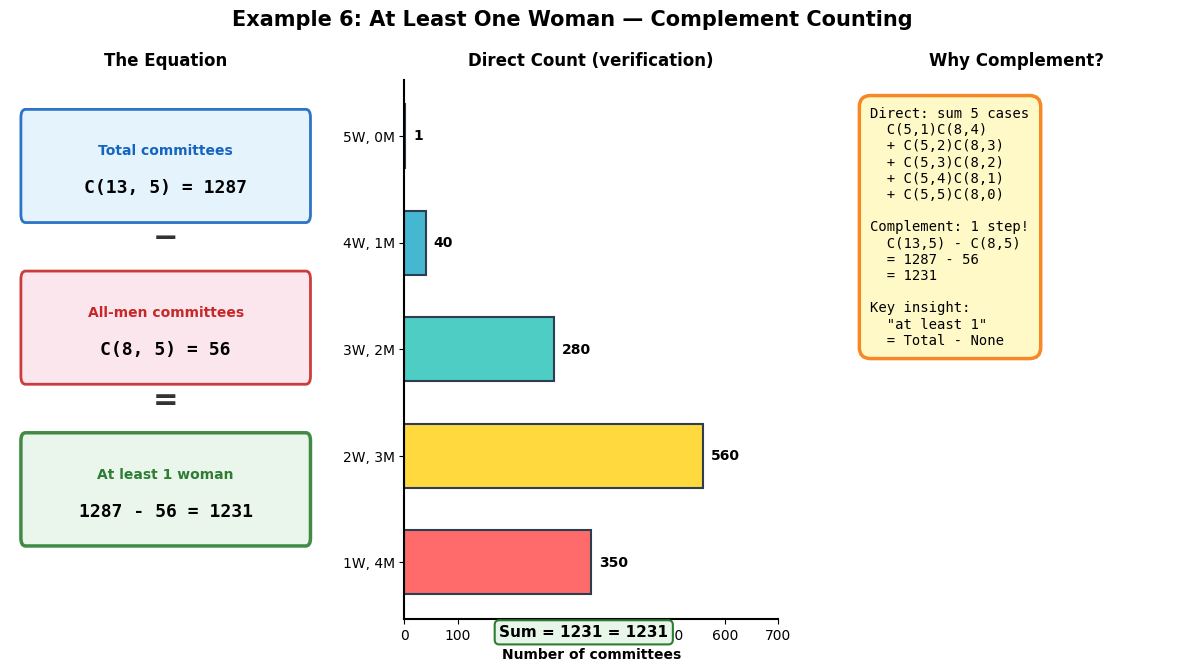

✓ Visual: At least one woman (complement counting)


In [25]:
# Visualize Example 6: At Least One Woman (Complement Counting) — improved
fig = plt.figure(figsize=(15, 7))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1.2, 1], wspace=0.25)
ax1, ax2, ax3 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])

fig.suptitle('Example 6: At Least One Woman — Complement Counting',
             fontsize=15, fontweight='bold', y=0.98)

total = C(13, 5)
no_women = C(8, 5)
answer = total - no_women

# Left: Visual equation with stacked bars
ax = ax1
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('The Equation', fontsize=12, fontweight='bold', pad=10)

# Total box
rect = patches.FancyBboxPatch((0.5, 7.5), 9, 1.8,
                               boxstyle='round,pad=0.15',
                               facecolor='#E3F2FD', edgecolor='#1565C0',
                               linewidth=2, alpha=0.9)
ax.add_patch(rect)
ax.text(5, 8.6, 'Total committees', fontsize=10, ha='center', fontweight='bold', color='#1565C0')
ax.text(5, 7.9, f'C(13, 5) = {total}', fontsize=13, ha='center',
        fontweight='bold', family='monospace')

# Minus
ax.text(5, 6.9, '−', fontsize=22, ha='center', fontweight='bold', color='#333')

# All-men box
rect = patches.FancyBboxPatch((0.5, 4.5), 9, 1.8,
                               boxstyle='round,pad=0.15',
                               facecolor='#FCE4EC', edgecolor='#C62828',
                               linewidth=2, alpha=0.9)
ax.add_patch(rect)
ax.text(5, 5.6, 'All-men committees', fontsize=10, ha='center', fontweight='bold', color='#C62828')
ax.text(5, 4.9, f'C(8, 5) = {no_women}', fontsize=13, ha='center',
        fontweight='bold', family='monospace')

# Equals
ax.text(5, 3.9, '=', fontsize=22, ha='center', fontweight='bold', color='#333')

# Result
rect = patches.FancyBboxPatch((0.5, 1.5), 9, 1.8,
                               boxstyle='round,pad=0.15',
                               facecolor='#E8F5E9', edgecolor='#2E7D32',
                               linewidth=2.5, alpha=0.9)
ax.add_patch(rect)
ax.text(5, 2.6, 'At least 1 woman', fontsize=10, ha='center', fontweight='bold', color='#2E7D32')
ax.text(5, 1.9, f'{total} - {no_women} = {answer}', fontsize=13, ha='center',
        fontweight='bold', family='monospace')

# Middle: Bar chart of all cases
ax = ax2
cases_w = list(range(1, 6))
case_values = [C(5, w) * C(8, 5 - w) for w in cases_w]
case_labels = [f'{w}W, {5-w}M' for w in cases_w]
colors_cases = ['#FF6B6B', '#FFD93D', '#4ECDC4', '#45B7D1', '#9B59B6']

bars2 = ax.barh(case_labels, case_values, color=colors_cases, edgecolor='#2C3E50',
                linewidth=1.5, height=0.6)

for bar, val in zip(bars2, case_values):
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Number of committees', fontsize=10, fontweight='bold')
ax.set_title('Direct Count (verification)', fontsize=12, fontweight='bold', pad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.set_xlim(0, max(case_values) * 1.25)

ax.text(max(case_values) * 0.6, -0.7, f'Sum = {sum(case_values)} = {answer}',
        fontsize=11, fontweight='bold', ha='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#E8F5E9',
                  edgecolor='#2E7D32', linewidth=1.5))

# Right: Why complement?
ax = ax3
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Why Complement?', fontsize=12, fontweight='bold', pad=10)

why_text = """Direct: sum 5 cases
  C(5,1)C(8,4)
  + C(5,2)C(8,3)
  + C(5,3)C(8,2)
  + C(5,4)C(8,1)
  + C(5,5)C(8,0)

Complement: 1 step!
  C(13,5) - C(8,5)
  = 1287 - 56
  = 1231

Key insight:
  "at least 1"
  = Total - None"""

ax.text(0.3, 9.5, why_text, fontsize=10, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='#FFF9C4',
                  edgecolor='#F57F17', linewidth=2.5, alpha=0.92))

plt.tight_layout()
plt.show()

print("✓ Visual: At least one woman (complement counting)")

### Example 7: Pizza Toppings

A pizza shop offers **10 toppings**. You can choose **any number** of toppings (including none).

Each topping is either on or off — **2 choices per topping** — so by the **product rule**: $2^{10} = 1024$ possible pizzas.

This equals: $C(10,0) + C(10,1) + C(10,2) + \cdots + C(10,10) = 2^{10}$

In [26]:
toppings = 10

print(f"Available toppings: {toppings}")
print()
print("Pizzas by number of toppings:")
total = 0
for r in range(toppings + 1):
    ways = C(toppings, r)
    total += ways
    print(f"  {r:>2} toppings: C({toppings}, {r:>2}) = {ways}")
print()
print(f"Total: {total} = 2^{toppings} = {2**toppings}")

Available toppings: 10

Pizzas by number of toppings:
   0 toppings: C(10,  0) = 1
   1 toppings: C(10,  1) = 10
   2 toppings: C(10,  2) = 45
   3 toppings: C(10,  3) = 120
   4 toppings: C(10,  4) = 210
   5 toppings: C(10,  5) = 252
   6 toppings: C(10,  6) = 210
   7 toppings: C(10,  7) = 120
   8 toppings: C(10,  8) = 45
   9 toppings: C(10,  9) = 10
  10 toppings: C(10, 10) = 1

Total: 1024 = 2^10 = 1024


/tmp/ipykernel_285025/3061187539.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


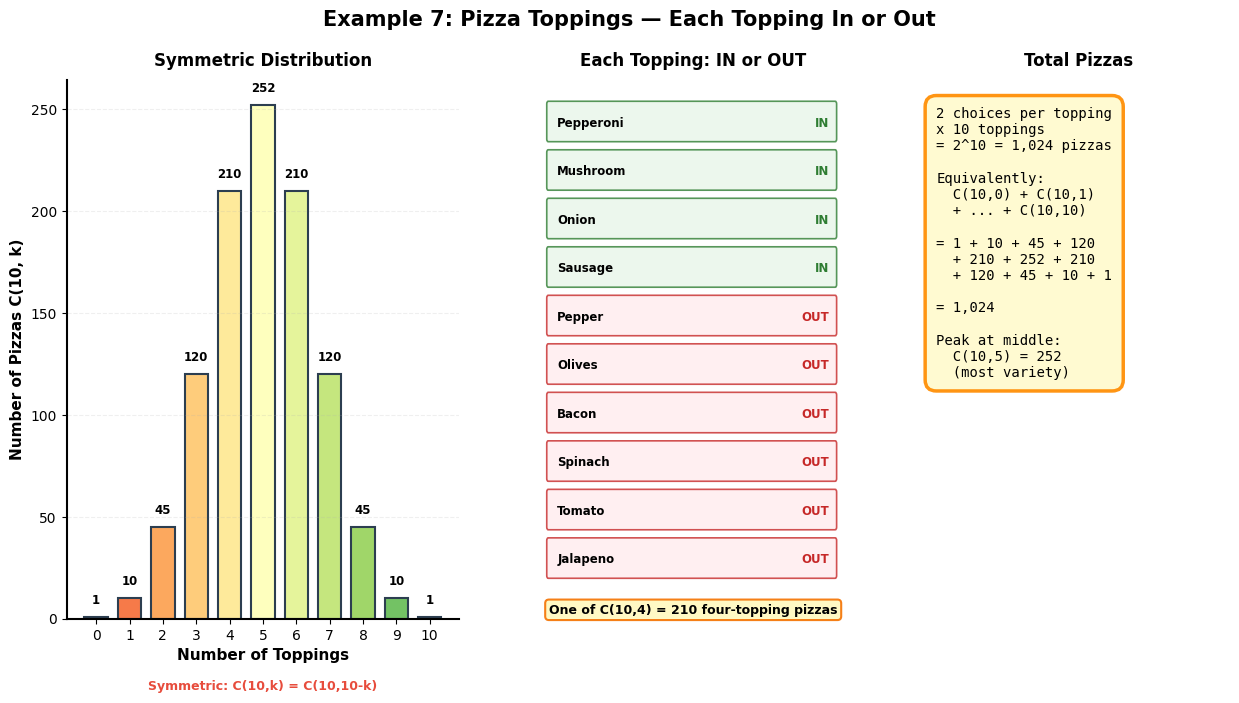

✓ Visual: Pizza toppings (2^n choices)


In [27]:
# Visualize Example 7: Pizza Toppings (2^n Choices) — improved
fig = plt.figure(figsize=(15, 7))
gs = fig.add_gridspec(1, 3, width_ratios=[1.3, 1, 1], wspace=0.25)
ax1, ax2, ax3 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])

fig.suptitle('Example 7: Pizza Toppings — Each Topping In or Out',
             fontsize=15, fontweight='bold', y=0.98)

# Left: Bell-curve-shaped bar chart
ax = ax1
topping_counts = list(range(11))
ways_list = [C(10, r) for r in topping_counts]
colors_bar = plt.cm.RdYlGn(np.linspace(0.15, 0.85, 11))

bars = ax.bar(topping_counts, ways_list, color=colors_bar, edgecolor='#2C3E50',
              linewidth=1.5, width=0.7)

for bar, val in zip(bars, ways_list):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., h + 5, str(val),
            ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xlabel('Number of Toppings', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Pizzas C(10, k)', fontsize=11, fontweight='bold')
ax.set_title('Symmetric Distribution', fontsize=12, fontweight='bold', pad=10)
ax.set_xticks(topping_counts)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.grid(axis='y', alpha=0.2, linestyle='--')

# Symmetry annotation
ax.annotate('', xy=(0, -25), xytext=(10, -25),
            arrowprops=dict(arrowstyle='<->', color='#E74C3C', lw=2))
ax.text(5, -35, 'Symmetric: C(10,k) = C(10,10-k)', ha='center',
        fontsize=9, fontweight='bold', color='#E74C3C')

# Middle: Binary choice visual
ax = ax2
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Each Topping: IN or OUT', fontsize=12, fontweight='bold', pad=10)

topping_names = ['Pepperoni', 'Mushroom', 'Onion', 'Sausage', 'Pepper',
                 'Olives', 'Bacon', 'Spinach', 'Tomato', 'Jalapeno']
# Show a sample pizza: first 4 in, rest out
for i, name in enumerate(topping_names):
    y = 9.2 - i * 0.9
    chosen = i < 4
    bg = '#E8F5E9' if chosen else '#FFEBEE'
    ec = '#2E7D32' if chosen else '#C62828'
    marker = 'IN' if chosen else 'OUT'
    
    rect = patches.FancyBboxPatch((0.2, y - 0.3), 9.5, 0.65,
                                   boxstyle='round,pad=0.05',
                                   facecolor=bg, edgecolor=ec,
                                   linewidth=1.2, alpha=0.8)
    ax.add_patch(rect)
    ax.text(0.5, y, name, fontsize=8.5, fontweight='bold', va='center')
    ax.text(9.5, y, marker, fontsize=8.5, fontweight='bold', va='center',
            ha='right', color=ec)

ax.text(5, 0.1, 'One of C(10,4) = 210 four-topping pizzas',
        ha='center', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF9C4',
                  edgecolor='#F57F17', linewidth=1.5))

# Right: Total count
ax = ax3
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Total Pizzas', fontsize=12, fontweight='bold', pad=10)

total_text = """2 choices per topping
x 10 toppings
= 2^10 = 1,024 pizzas

Equivalently:
  C(10,0) + C(10,1)
  + ... + C(10,10)

= 1 + 10 + 45 + 120
  + 210 + 252 + 210
  + 120 + 45 + 10 + 1

= 1,024

Peak at middle:
  C(10,5) = 252
  (most variety)"""

ax.text(0.3, 9.5, total_text, fontsize=10, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='#FFFACD',
                  edgecolor='#FF8C00', linewidth=2.5, alpha=0.92))

plt.tight_layout()
plt.show()

print("✓ Visual: Pizza toppings (2^n choices)")

---
## 6. Permutations vs Combinations — When to Use Which?

The key question is always: **does order matter?**

| Scenario | Order matters? | Formula |
|----------|:-------------:|--------|
| Arranging books on a shelf | Yes | $P(n, r)$ |
| Assigning President, VP, Secretary | Yes | $P(n, r)$ |
| Forming a committee (no positions) | No | $C(n, r)$ |
| Choosing lottery numbers | No | $C(n, r)$ |
| Picking a hand of cards | No | $C(n, r)$ |
| Ranking contestants (1st, 2nd, 3rd) | Yes | $P(n, r)$ |
| Selecting a team | No | $C(n, r)$ |

In [28]:
# Side-by-side comparison
print(f"{'n':>3} {'r':>3} {'P(n,r)':>12} {'C(n,r)':>12} {'Ratio P/C':>12}")
print("-" * 46)
for n, r in [(5, 2), (10, 3), (20, 5), (52, 5), (100, 2)]:
    p = P(n, r)
    c = C(n, r)
    print(f"{n:>3} {r:>3} {p:>12,} {c:>12,} {p//c:>12,} = {r}!")

  n   r       P(n,r)       C(n,r)    Ratio P/C
----------------------------------------------
  5   2           20           10            2 = 2!
 10   3          720          120            6 = 3!
 20   5    1,860,480       15,504          120 = 5!
 52   5  311,875,200    2,598,960          120 = 5!
100   2        9,900        4,950            2 = 2!


/tmp/ipykernel_285025/3261569897.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


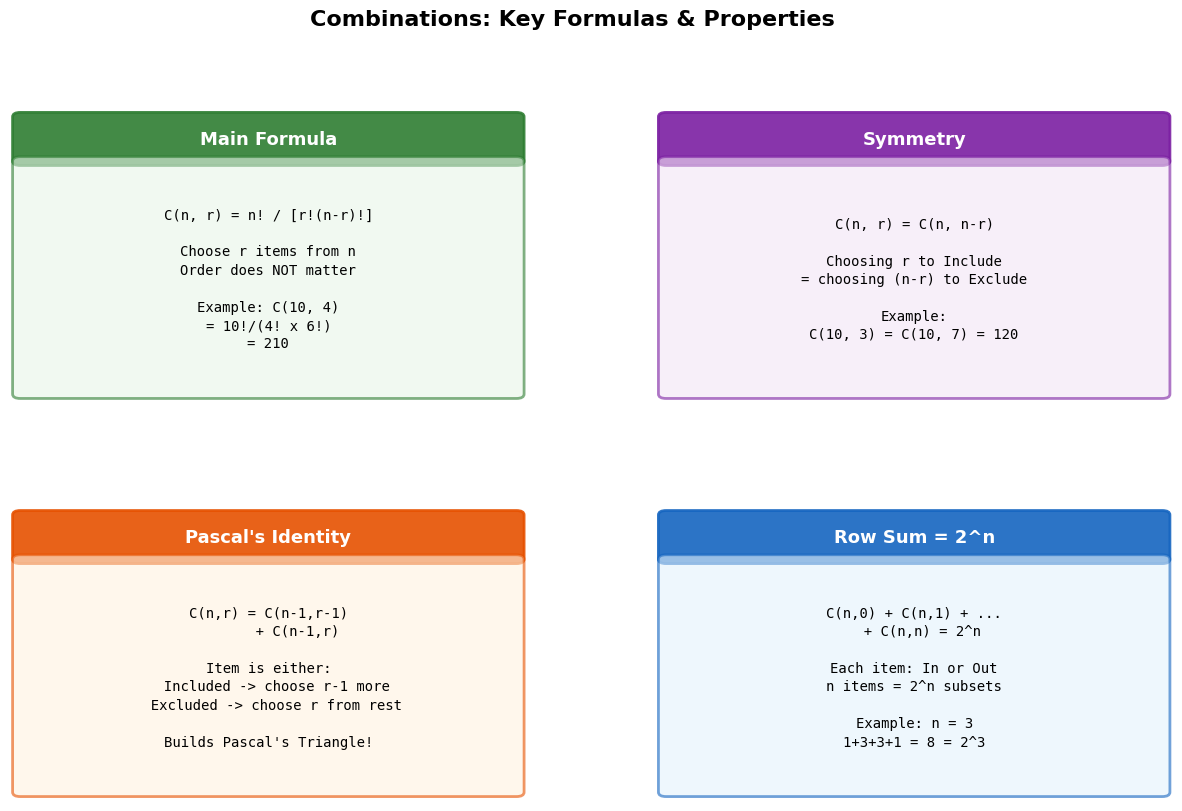

✓ Visual: Combinations formulas summary


In [29]:
# Visualize key formulas summary for combinations — improved
fig = plt.figure(figsize=(15, 9))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.25)

fig.suptitle('Combinations: Key Formulas & Properties',
             fontsize=16, fontweight='bold', y=0.99)

# Card-style formula boxes
cards = [
    (gs[0, 0], 'Main Formula', '#E8F5E9', '#2E7D32',
     'C(n, r) = n! / [r!(n-r)!]\n\nChoose r items from n\nOrder does NOT matter\n\nExample: C(10, 4)\n= 10!/(4! x 6!)\n= 210'),
    (gs[0, 1], 'Symmetry', '#F3E5F5', '#7B1FA2',
     'C(n, r) = C(n, n-r)\n\nChoosing r to Include\n= choosing (n-r) to Exclude\n\nExample:\nC(10, 3) = C(10, 7) = 120'),
    (gs[1, 0], "Pascal's Identity", '#FFF3E0', '#E65100',
     'C(n,r) = C(n-1,r-1)\n       + C(n-1,r)\n\nItem is either:\n  Included -> choose r-1 more\n  Excluded -> choose r from rest\n\nBuilds Pascal\'s Triangle!'),
    (gs[1, 1], 'Row Sum = 2^n', '#E3F2FD', '#1565C0',
     'C(n,0) + C(n,1) + ...\n  + C(n,n) = 2^n\n\nEach item: In or Out\nn items = 2^n subsets\n\nExample: n = 3\n1+3+3+1 = 8 = 2^3'),
]

for gs_pos, title, bg, ec, content in cards:
    ax = fig.add_subplot(gs_pos)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    
    # Title bar
    title_rect = patches.FancyBboxPatch((0.2, 8.2), 9.6, 1.5,
                                         boxstyle='round,pad=0.15',
                                         facecolor=ec, edgecolor=ec,
                                         linewidth=2, alpha=0.9)
    ax.add_patch(title_rect)
    ax.text(5, 8.95, title, ha='center', va='center',
            fontsize=13, fontweight='bold', color='white')
    
    # Content area
    body_rect = patches.FancyBboxPatch((0.2, 0.3), 9.6, 7.9,
                                        boxstyle='round,pad=0.15',
                                        facecolor=bg, edgecolor=ec,
                                        linewidth=2, alpha=0.6)
    ax.add_patch(body_rect)
    ax.text(5, 4.2, content, ha='center', va='center',
            fontsize=10, family='monospace', linespacing=1.4)

plt.tight_layout()
plt.show()

print("✓ Visual: Combinations formulas summary")

/tmp/ipykernel_285025/3963945564.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


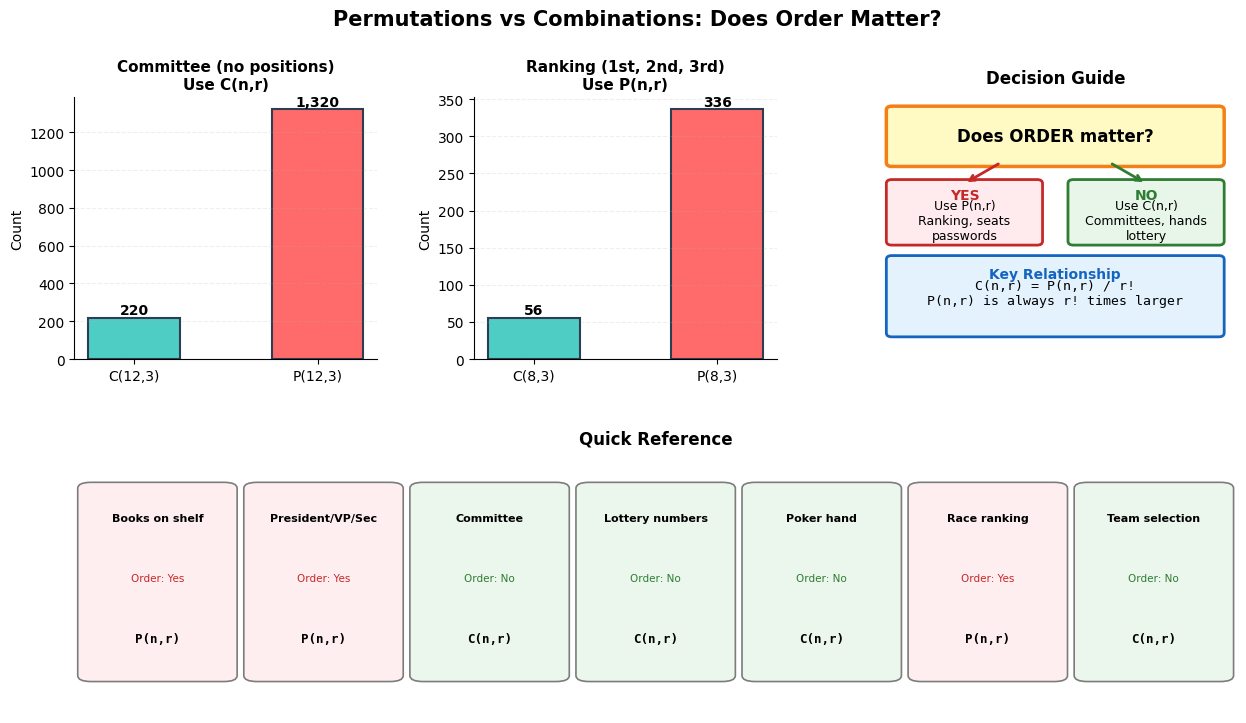

✓ Visual: Permutations vs Combinations decision guide


In [30]:
# Visualize Permutations vs Combinations comparison — improved
fig = plt.figure(figsize=(15, 8))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3,
                      width_ratios=[1, 1, 1.2])

fig.suptitle('Permutations vs Combinations: Does Order Matter?',
             fontsize=15, fontweight='bold', y=0.99)

# Top-left: Committee scenario bar
ax = fig.add_subplot(gs[0, 0])
vals = [C(12, 3), P(12, 3)]
colors_bar = ['#4ECDC4', '#FF6B6B']
bars = ax.bar(['C(12,3)', 'P(12,3)'], vals, color=colors_bar,
              edgecolor='#2C3E50', linewidth=1.5, width=0.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 20,
            f'{val:,}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Committee (no positions)\nUse C(n,r)', fontsize=11, fontweight='bold')
ax.set_ylabel('Count', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2, linestyle='--')

# Top-middle: Ranking scenario bar
ax = fig.add_subplot(gs[0, 1])
vals = [C(8, 3), P(8, 3)]
bars = ax.bar(['C(8,3)', 'P(8,3)'], vals, color=colors_bar,
              edgecolor='#2C3E50', linewidth=1.5, width=0.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 5,
            str(val), ha='center', fontsize=10, fontweight='bold')
ax.set_title('Ranking (1st, 2nd, 3rd)\nUse P(n,r)', fontsize=11, fontweight='bold')
ax.set_ylabel('Count', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2, linestyle='--')

# Top-right: Decision flowchart
ax = fig.add_subplot(gs[0, 2])
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Decision Guide', fontsize=12, fontweight='bold', pad=10)

# Question box
rect = patches.FancyBboxPatch((0.5, 7.5), 9, 2,
                               boxstyle='round,pad=0.15',
                               facecolor='#FFF9C4', edgecolor='#F57F17',
                               linewidth=2.5)
ax.add_patch(rect)
ax.text(5, 8.5, 'Does ORDER matter?', ha='center', va='center',
        fontsize=12, fontweight='bold')

# YES branch
rect = patches.FancyBboxPatch((0.5, 4.5), 4, 2.2,
                               boxstyle='round,pad=0.15',
                               facecolor='#FFEBEE', edgecolor='#C62828',
                               linewidth=2)
ax.add_patch(rect)
ax.text(2.5, 6.1, 'YES', fontsize=10, fontweight='bold', ha='center', color='#C62828')
ax.text(2.5, 5.3, 'Use P(n,r)\nRanking, seats\npasswords', ha='center',
        fontsize=9, va='center')
ax.annotate('', xy=(2.5, 6.7), xytext=(3.5, 7.5),
            arrowprops=dict(arrowstyle='->', color='#C62828', lw=2))

# NO branch
rect = patches.FancyBboxPatch((5.5, 4.5), 4, 2.2,
                               boxstyle='round,pad=0.15',
                               facecolor='#E8F5E9', edgecolor='#2E7D32',
                               linewidth=2)
ax.add_patch(rect)
ax.text(7.5, 6.1, 'NO', fontsize=10, fontweight='bold', ha='center', color='#2E7D32')
ax.text(7.5, 5.3, 'Use C(n,r)\nCommittees, hands\nlottery', ha='center',
        fontsize=9, va='center')
ax.annotate('', xy=(7.5, 6.7), xytext=(6.5, 7.5),
            arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=2))

# Relationship
rect = patches.FancyBboxPatch((0.5, 1), 9, 2.8,
                               boxstyle='round,pad=0.15',
                               facecolor='#E3F2FD', edgecolor='#1565C0',
                               linewidth=2)
ax.add_patch(rect)
ax.text(5, 3.1, 'Key Relationship', fontsize=10, fontweight='bold',
        ha='center', color='#1565C0')
ax.text(5, 2.1, 'C(n,r) = P(n,r) / r!\nP(n,r) is always r! times larger',
        ha='center', fontsize=9.5, family='monospace')

# Bottom row spans full width
ax = fig.add_subplot(gs[1, :])
# Comparison table as visual
scenarios = [
    ('Books on shelf', 'Yes', 'P(n,r)', '#FFEBEE'),
    ('President/VP/Sec', 'Yes', 'P(n,r)', '#FFEBEE'),
    ('Committee', 'No', 'C(n,r)', '#E8F5E9'),
    ('Lottery numbers', 'No', 'C(n,r)', '#E8F5E9'),
    ('Poker hand', 'No', 'C(n,r)', '#E8F5E9'),
    ('Race ranking', 'Yes', 'P(n,r)', '#FFEBEE'),
    ('Team selection', 'No', 'C(n,r)', '#E8F5E9'),
]

ax.set_xlim(-0.5, len(scenarios) - 0.5)
ax.set_ylim(-0.5, 3)
ax.axis('off')
ax.set_title('Quick Reference', fontsize=12, fontweight='bold', pad=5)

for i, (scenario, order, formula, bg) in enumerate(scenarios):
    x = i
    # Card
    rect = patches.FancyBboxPatch((x - 0.4, 0), 0.8, 2.5,
                                   boxstyle='round,pad=0.08',
                                   facecolor=bg, edgecolor='#666',
                                   linewidth=1.2, alpha=0.85)
    ax.add_patch(rect)
    ax.text(x, 2.1, scenario, ha='center', va='center', fontsize=8,
            fontweight='bold', wrap=True)
    ax.text(x, 1.3, f'Order: {order}', ha='center', va='center', fontsize=7.5,
            color='#C62828' if order == 'Yes' else '#2E7D32')
    ax.text(x, 0.5, formula, ha='center', va='center', fontsize=9,
            fontweight='bold', family='monospace')

plt.tight_layout()
plt.show()

print("✓ Visual: Permutations vs Combinations decision guide")

---
## 7. Summary of Formulas

| Concept | Formula | Use when |
|---------|---------|----------|
| Permutation (all $n$) | $n!$ | Arrange all items, order matters |
| Permutation ($r$ of $n$) | $P(n,r) = \frac{n!}{(n-r)!}$ | Arrange $r$ items, order matters |
| Combination | $C(n,r) = \frac{n!}{r!(n-r)!}$ | Choose $r$ items, order does NOT matter |
| Relationship | $C(n,r) = \frac{P(n,r)}{r!}$ | Combination = Permutation ÷ orderings |

---
## 8. Practice Problems

Try solving these on your own before running the solution cells!

### Problem 1: Fruit Selection

A fruit basket contains **12 different fruits**. You pick **4** to take home.

How many different selections are possible?

In [31]:
# SOLUTION
n, r = 12, 4
result = C(n, r)

print(f"C({n}, {r}) = {n}! / ({r}! × {n-r}!) = {result}")

C(12, 4) = 12! / (4! × 8!) = 495


### Problem 2: Diagonals of a Polygon

A convex polygon has **10 vertices**.

**Part A**: How many line segments can be drawn between vertices?

**Part B**: How many of those are **diagonals** (not sides)?

Hint: A line segment connects 2 vertices. The polygon has 10 sides.

In [32]:
# SOLUTION
vertices = 10
sides = 10  # a 10-gon has 10 sides

# Part A: Choose 2 vertices to connect
all_segments = C(vertices, 2)
print(f"Part A: Line segments = C({vertices}, 2) = {all_segments}")

# Part B: Diagonals = All segments - Sides
diagonals = all_segments - sides
print(f"Part B: Diagonals = {all_segments} - {sides} = {diagonals}")

Part A: Line segments = C(10, 2) = 45
Part B: Diagonals = 45 - 10 = 35


/tmp/ipykernel_285025/3910740417.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


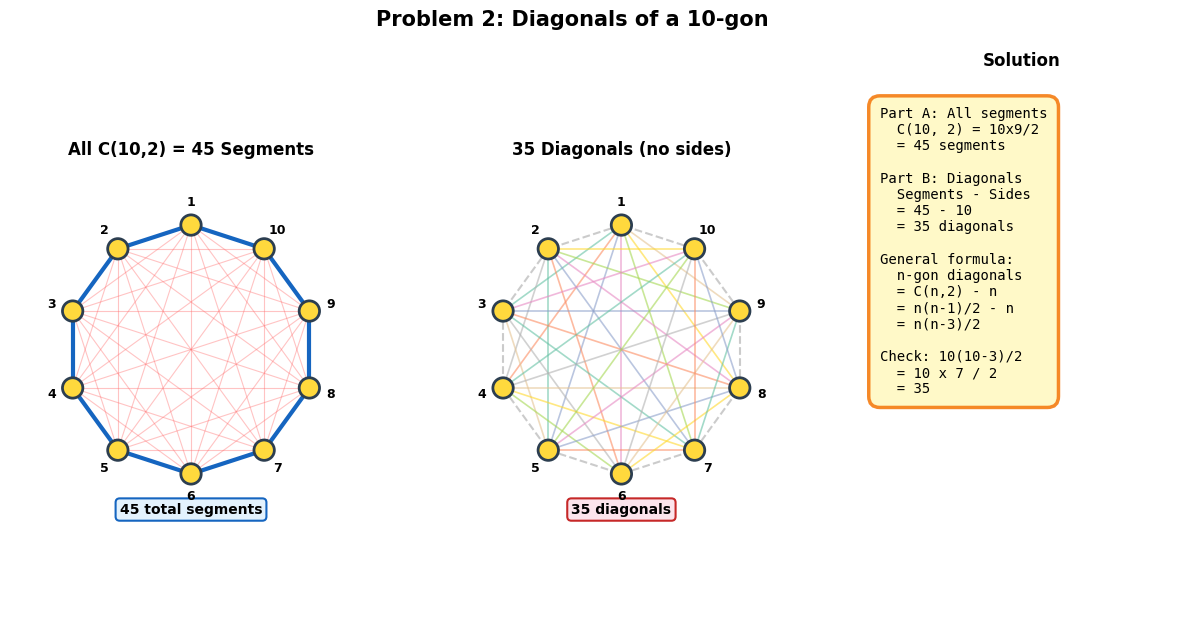

✓ Visual: Polygon diagonals problem


In [33]:
# Visualize Problem 2: Polygon Diagonals — improved
fig = plt.figure(figsize=(15, 7))
gs = fig.add_gridspec(1, 3, width_ratios=[1.2, 1.2, 1], wspace=0.2)
ax1, ax2, ax3 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])

fig.suptitle('Problem 2: Diagonals of a 10-gon',
             fontsize=15, fontweight='bold', y=0.98)

n_vertices = 10
angles = np.linspace(np.pi/2, np.pi/2 + 2*np.pi, n_vertices, endpoint=False)
radius = 2.2

vertices = [(radius * np.cos(a), radius * np.sin(a)) for a in angles]

# Left: Show all line segments (sides in blue, diagonals in red)
ax = ax1
ax.set_xlim(-3.2, 3.2)
ax.set_ylim(-3.2, 3.2)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f'All C(10,2) = {C(10,2)} Segments', fontsize=12, fontweight='bold', pad=10)

# Draw all diagonals first (behind)
for i in range(n_vertices):
    for j in range(i + 2, n_vertices):
        if not (i == 0 and j == n_vertices - 1):  # skip side
            x1, y1 = vertices[i]
            x2, y2 = vertices[j]
            ax.plot([x1, x2], [y1, y2], color='#FF6B6B', linewidth=0.8, alpha=0.4)

# Draw sides on top
for i in range(n_vertices):
    x1, y1 = vertices[i]
    x2, y2 = vertices[(i + 1) % n_vertices]
    ax.plot([x1, x2], [y1, y2], color='#1565C0', linewidth=3, solid_capstyle='round')

# Draw vertices
for i, (x, y) in enumerate(vertices):
    ax.add_patch(patches.Circle((x, y), 0.18, facecolor='#FFD93D',
                                 edgecolor='#2C3E50', linewidth=2, zorder=5))
    ax.text(x * 1.18, y * 1.18, str(i+1), ha='center', va='center',
            fontsize=9, fontweight='bold', zorder=6)

ax.text(0, -2.9, f'{C(10,2)} total segments', ha='center', fontsize=10,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#E3F2FD',
                  edgecolor='#1565C0', linewidth=1.5))

# Middle: Highlight diagonals only
ax = ax2
ax.set_xlim(-3.2, 3.2)
ax.set_ylim(-3.2, 3.2)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f'{C(10,2) - 10} Diagonals (no sides)', fontsize=12, fontweight='bold', pad=10)

# Draw diagonals with gradient colors
diag_colors = plt.cm.Set2(np.linspace(0, 1, 8))
d_idx = 0
for i in range(n_vertices):
    for j in range(i + 2, n_vertices):
        if not (i == 0 and j == n_vertices - 1):
            x1, y1 = vertices[i]
            x2, y2 = vertices[j]
            ax.plot([x1, x2], [y1, y2], color=diag_colors[d_idx % 8],
                    linewidth=1.2, alpha=0.6)
            d_idx += 1

# Draw polygon outline (dashed, subtle)
for i in range(n_vertices):
    x1, y1 = vertices[i]
    x2, y2 = vertices[(i + 1) % n_vertices]
    ax.plot([x1, x2], [y1, y2], color='#999', linewidth=1.5, linestyle='--', alpha=0.5)

# Draw vertices
for i, (x, y) in enumerate(vertices):
    ax.add_patch(patches.Circle((x, y), 0.18, facecolor='#FFD93D',
                                 edgecolor='#2C3E50', linewidth=2, zorder=5))
    ax.text(x * 1.18, y * 1.18, str(i+1), ha='center', va='center',
            fontsize=9, fontweight='bold', zorder=6)

ax.text(0, -2.9, f'{C(10,2) - 10} diagonals', ha='center', fontsize=10,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FCE4EC',
                  edgecolor='#C62828', linewidth=1.5))

# Right: Calculation
ax = ax3
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Solution', fontsize=12, fontweight='bold', pad=10)

v = 10
sol_text = f"""Part A: All segments
  C({v}, 2) = {v}x{v-1}/2
  = {C(v,2)} segments

Part B: Diagonals
  Segments - Sides
  = {C(v,2)} - {v}
  = {C(v,2) - v} diagonals

General formula:
  n-gon diagonals
  = C(n,2) - n
  = n(n-1)/2 - n
  = n(n-3)/2

Check: 10(10-3)/2
  = 10 x 7 / 2
  = 35"""

ax.text(0.3, 9.5, sol_text, fontsize=10, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='#FFF9C4',
                  edgecolor='#F57F17', linewidth=2.5, alpha=0.92))

plt.tight_layout()
plt.show()

print("✓ Visual: Polygon diagonals problem")

### Problem 3: Team Formation with Constraints

From **6 seniors** and **8 juniors**, form a team of **5** with **at least 2 seniors**.

Hint: Use the sum rule over valid cases (2, 3, 4, or 5 seniors).

In [34]:
# SOLUTION
seniors = 6
juniors = 8
team_size = 5

# Sum rule: 2 seniors OR 3 seniors OR 4 seniors OR 5 seniors
total = 0
for s in range(2, min(seniors, team_size) + 1):
    j = team_size - s
    if j > juniors:
        continue
    ways = C(seniors, s) * C(juniors, j)
    print(f"{s} seniors, {j} juniors: C({seniors},{s}) × C({juniors},{j}) = {C(seniors,s)} × {C(juniors,j)} = {ways}")
    total += ways

print(f"Total: {total}")
print()

# Verify with complement: Total - (0 seniors) - (1 senior)
all_teams = C(seniors + juniors, team_size)
zero_seniors = C(seniors, 0) * C(juniors, 5)
one_senior = C(seniors, 1) * C(juniors, 4)
complement = all_teams - zero_seniors - one_senior
print(f"Complement check: {all_teams} - {zero_seniors} - {one_senior} = {complement}")
print(f"Match: {'✓' if total == complement else '✗'}")

2 seniors, 3 juniors: C(6,2) × C(8,3) = 15 × 56 = 840
3 seniors, 2 juniors: C(6,3) × C(8,2) = 20 × 28 = 560
4 seniors, 1 juniors: C(6,4) × C(8,1) = 15 × 8 = 120
5 seniors, 0 juniors: C(6,5) × C(8,0) = 6 × 1 = 6
Total: 1526

Complement check: 2002 - 56 - 420 = 1526
Match: ✓


### Problem 4: Binary Strings by Weight

How many **binary strings** of length **10** have **exactly 4** ones?

Hint: Choosing which 4 positions (out of 10) are 1s determines the string.

In [35]:
# SOLUTION
# Choose 4 positions out of 10 for the 1s, rest are 0s
n, r = 10, 4
result = C(n, r)

print(f"Binary strings of length {n} with exactly {r} ones:")
print(f"C({n}, {r}) = {result}")
print()

# Verify: total binary strings = sum over all weights
verify = 0
for k in range(n + 1):
    verify += C(n, k)
print(f"Sum C({n},0) + C({n},1) + ... + C({n},{n}) = {verify} = 2^{n}")

Binary strings of length 10 with exactly 4 ones:
C(10, 4) = 210

Sum C(10,0) + C(10,1) + ... + C(10,10) = 1024 = 2^10


### Problem 5: Paths on a Grid

You are at the **top-left** corner of a **6 × 4 grid** and want to reach the **bottom-right** corner. You can only move **right** or **down**.

How many distinct paths are there?

Hint: Every path consists of exactly 6 right-moves and 4 down-moves (10 moves total). The question is: in what order?

In [36]:
# SOLUTION
right_moves = 6
down_moves = 4
total_moves = right_moves + down_moves

# Choose which 6 of the 10 moves are "right" (the rest are "down")
# Equivalently: choose which 4 are "down"
result = C(total_moves, right_moves)

print(f"Grid: {right_moves} × {down_moves}")
print(f"Total moves: {total_moves} ({right_moves} right + {down_moves} down)")
print(f"Paths = C({total_moves}, {right_moves}) = C({total_moves}, {down_moves}) = {result}")
print()

# This is also permutations with repetition: 10! / (6! × 4!)
perm_rep = math.factorial(total_moves) // (math.factorial(right_moves) * math.factorial(down_moves))
print(f"Same as permutations with repetition: {total_moves}! / ({right_moves}! × {down_moves}!) = {perm_rep}")
print(f"Match: {'✓' if result == perm_rep else '✗'}")

Grid: 6 × 4
Total moves: 10 (6 right + 4 down)
Paths = C(10, 6) = C(10, 4) = 210

Same as permutations with repetition: 10! / (6! × 4!) = 210
Match: ✓


/tmp/ipykernel_285025/1671891107.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


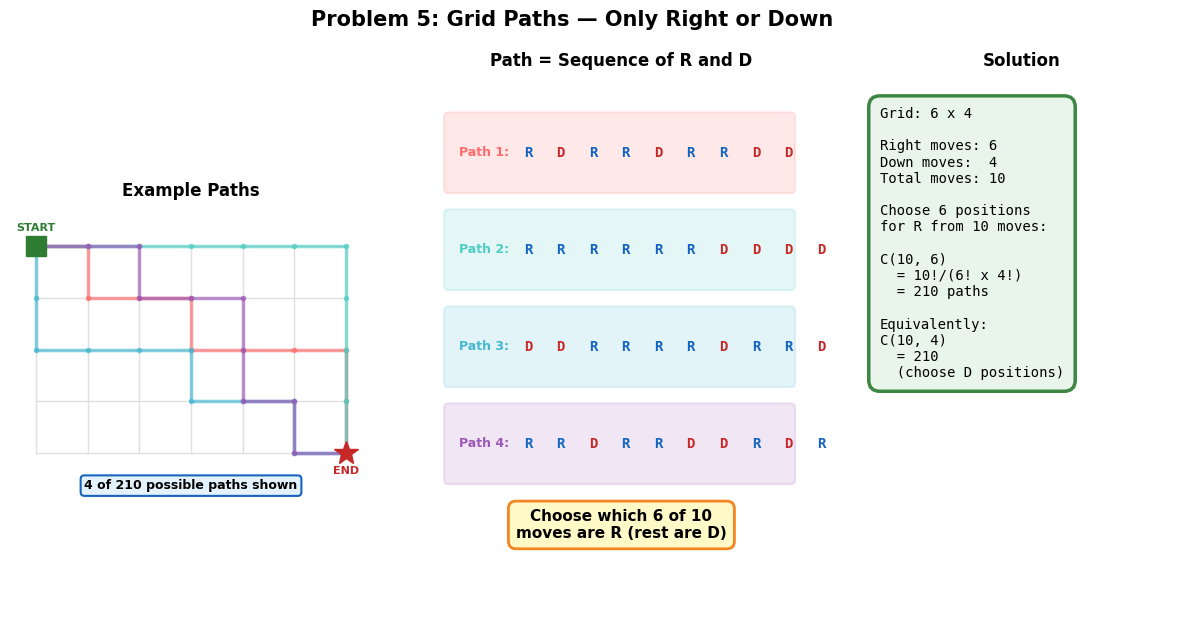

✓ Visual: Grid paths problem — 210 paths


In [37]:
# Visualize Problem 5: Grid Paths — improved
fig = plt.figure(figsize=(15, 7))
gs = fig.add_gridspec(1, 3, width_ratios=[1.2, 1.2, 1], wspace=0.2)
ax1, ax2, ax3 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])

fig.suptitle('Problem 5: Grid Paths — Only Right or Down',
             fontsize=15, fontweight='bold', y=0.98)

grid_width, grid_height = 6, 4
total_moves = grid_width + grid_height

# Left: Grid with multiple example paths
ax = ax1
ax.set_title('Example Paths', fontsize=12, fontweight='bold', pad=10)

# Draw grid
for x in range(grid_width + 1):
    ax.plot([x, x], [0, grid_height], color='#E0E0E0', linewidth=1)
for y in range(grid_height + 1):
    ax.plot([0, grid_width], [y, y], color='#E0E0E0', linewidth=1)

# Example paths with different colors
example_paths = [
    [(0, 4), (1, 4), (1, 3), (2, 3), (3, 3), (3, 2), (4, 2), (5, 2), (6, 2), (6, 1), (6, 0)],
    [(0, 4), (1, 4), (2, 4), (3, 4), (4, 4), (5, 4), (6, 4), (6, 3), (6, 2), (6, 1), (6, 0)],
    [(0, 4), (0, 3), (0, 2), (1, 2), (2, 2), (3, 2), (3, 1), (4, 1), (5, 1), (5, 0), (6, 0)],
    [(0, 4), (1, 4), (2, 4), (2, 3), (3, 3), (4, 3), (4, 2), (4, 1), (5, 1), (5, 0), (6, 0)],
]
colors_path = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#9B59B6']

for path, color in zip(example_paths, colors_path):
    xs, ys = zip(*path)
    ax.plot(xs, ys, color=color, linewidth=2.5, alpha=0.65, marker='o', markersize=3)

# Start and end markers
ax.plot(0, grid_height, 's', color='#2E7D32', markersize=14, zorder=10)
ax.text(0, grid_height + 0.3, 'START', ha='center', fontsize=8, fontweight='bold', color='#2E7D32')
ax.plot(grid_width, 0, '*', color='#C62828', markersize=18, zorder=10)
ax.text(grid_width, -0.4, 'END', ha='center', fontsize=8, fontweight='bold', color='#C62828')

ax.set_xlim(-0.5, grid_width + 0.5)
ax.set_ylim(-0.7, grid_height + 0.7)
ax.set_aspect('equal')
ax.axis('off')
ax.text(3, -0.7, f'4 of {C(total_moves, grid_width):,} possible paths shown',
        ha='center', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#E3F2FD', edgecolor='#1565C0', linewidth=1.5))

# Middle: Move encoding
ax = ax2
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Path = Sequence of R and D', fontsize=12, fontweight='bold', pad=10)

# Show each path as encoded string
path_encodings = [
    'R D R R D R R D D  ',  # path 1 approx
    'R R R R R R D D D D',  # path 2
    'D D R R R R D R R D',  # path 3 approx
    'R R D R R D D R D R',  # path 4 approx
]

for i, (enc, color) in enumerate(zip(path_encodings, colors_path)):
    y = 8.5 - i * 1.8
    rect = patches.FancyBboxPatch((0.2, y - 0.5), 9.5, 1.3,
                                   boxstyle='round,pad=0.1',
                                   facecolor=color, alpha=0.15,
                                   edgecolor=color, linewidth=1.5)
    ax.add_patch(rect)
    ax.text(0.5, y + 0.15, f'Path {i+1}:', fontsize=9, fontweight='bold',
            va='center', color=color)
    # Color-code R and D
    x_start = 2.3
    for ch in enc:
        if ch == ' ':
            x_start += 0.25
            continue
        c = '#1565C0' if ch == 'R' else '#C62828'
        ax.text(x_start, y + 0.15, ch, fontsize=10, fontweight='bold',
                va='center', family='monospace', color=c)
        x_start += 0.65

# Key insight
ax.text(5, 1.5, f'Choose which {grid_width} of {total_moves}\nmoves are R (rest are D)',
        ha='center', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF9C4',
                  edgecolor='#F57F17', linewidth=2, alpha=0.95))

# Right: Solution
ax = ax3
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Solution', fontsize=12, fontweight='bold', pad=10)

sol_text = f"""Grid: {grid_width} x {grid_height}

Right moves: {grid_width}
Down moves:  {grid_height}
Total moves: {total_moves}

Choose {grid_width} positions
for R from {total_moves} moves:

C({total_moves}, {grid_width})
  = {total_moves}!/({grid_width}! x {grid_height}!)
  = {C(total_moves, grid_width):,} paths

Equivalently:
C({total_moves}, {grid_height})
  = {C(total_moves, grid_height):,}
  (choose D positions)"""

ax.text(0.3, 9.5, sol_text, fontsize=10, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='#E8F5E9',
                  edgecolor='#2E7D32', linewidth=2.5, alpha=0.92))

plt.tight_layout()
plt.show()

print(f"✓ Visual: Grid paths problem — {C(total_moves, grid_width):,} paths")

### Problem 6: Combination Identity

Verify that for $n = 20$:

$$\sum_{r=0}^{20} C(20, r)^2 = C(40, 20)$$

This is known as **Vandermonde's Identity** (special case).

In [38]:
# SOLUTION
n = 20

lhs = 0
for r in range(n + 1):
    lhs += C(n, r) ** 2

rhs = C(2 * n, n)

print(f"Sum of C({n}, r)² for r = 0 to {n}: {lhs:,}")
print(f"C({2*n}, {n}):                         {rhs:,}")
print(f"Match: {'✓' if lhs == rhs else '✗'}")

Sum of C(20, r)² for r = 0 to 20: 137,846,528,820
C(40, 20):                         137,846,528,820
Match: ✓


---
## 9. What's Next?

In the next notebook, we explore **Stars and Bars** — a powerful technique for counting the number of ways to distribute identical objects into distinct bins, or equivalently, counting combinations **with repetition allowed**.